# Actividad 1


Esta actividad consiste en la realización de la actividad evaluable número 1 asociada al bloque 1 de la asignatura. En ella, se realizará un ejercicio de clasificaciónn, empleando 3 métodos: Naive Bayes, K-NN y Árboles de Decisión.

## Importación de Librerías

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source

## Carga de los Datos

Tal y como menciona el enunciado, los datos provienen de la web InsideAirbnb, dedicada al estudio de alquileres vacacionales ofrecidos en la plataforma Airbnb. El fichero es una versión editada de los datos de Madrid en abril de 2017.

Cargamos los datos y mostraremos una vista previa:

In [2]:
# Carga de datos
df = pd.read_csv('airbnb.csv')
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Centro,Justicia,40.424715,-3.698638,Entire home/apt,49,28,35,0.42,1,99
1,Centro,Embajadores,40.413418,-3.706838,Entire home/apt,80,5,18,0.30,1,188
2,Moncloa - Aravaca,Argüelles,40.424920,-3.713446,Entire home/apt,40,2,21,0.25,9,195
3,Moncloa - Aravaca,Casa de Campo,40.431027,-3.724586,Entire home/apt,55,2,3,0.13,9,334
4,Latina,Cármenes,40.403410,-3.740842,Private room,16,2,23,0.76,2,250
...,...,...,...,...,...,...,...,...,...,...,...
13316,Centro,Justicia,40.427500,-3.698354,Private room,14,1,0,0.00,1,10
13317,Chamberí,Gaztambide,40.431187,-3.711909,Entire home/apt,47,1,0,0.00,7,354
13318,Centro,Palacio,40.413552,-3.711461,Entire home/apt,60,2,0,0.00,1,17
13319,Centro,Universidad,40.425400,-3.709921,Entire home/apt,150,5,0,0.00,1,15


Tenemos 13321 entradas de datos, con 11 columnas. 

Tras analizar la vista previa, concluimos que esta es la descripción de cada una de las columnas:

| **Columna**                               | **Descripción**                                                                       |
|-------------------------------------------|---------------------------------------------------------------------------------------|
| neighbourhood_group                       | Agrupación de vecindario en la que se encuentra la propiedad.                         |
| neighbourhood                             | Nombre del vecindario de la propiedad (más exacto).                                   |
| latitude                                  | Latitud geográfica.                                                                   |
| longitude                                 | Longitud geográfica.                                                                  |
| room_type                                 | Tipo de habitación ofrecida (entera, privada, compartida).                            |
| price                                     | Precio por noche.                                                                     |
| minimum_nights                            | Número mínimo de noches requeridas para reservar.                                     |
| number_of_reviews                         | Cantidad total de reseñas.                                                            |
| reviews_per_month                         | Cantidad promedio de reseñas mensualmente.                                            |
| calculated_host_listings_count            | Número total de listados que posee el anfitrión en Airbnb.                            |
| availability_365                          | Número de días al año en que la propiedad está disponible para ser alquilada.         |

La tarea consiste en clasificar los datos según el tipo de alojamiento (columna `room_type`) a partir del resto de características.

## Estudio Estadístico Inicial

Comenzaremos realizando un análisis exploratorio de los datos (o *Exploratory Data Analysis* - EDA en inglés).

### Información del Dataframe: tipos de datos, valores nulos, duplicados

El método `.info()` nos proporciona un resumen del DataFrame, mostrando el numero de filas, el nombre de cada columna, tipos de datos y número de valores no nulos que tenemos.

In [3]:
# Ver información del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             13321 non-null  object 
 1   neighbourhood                   13321 non-null  object 
 2   latitude                        13321 non-null  float64
 3   longitude                       13321 non-null  float64
 4   room_type                       13321 non-null  object 
 5   price                           13321 non-null  int64  
 6   minimum_nights                  13321 non-null  int64  
 7   number_of_reviews               13321 non-null  int64  
 8   reviews_per_month               13321 non-null  float64
 9   calculated_host_listings_count  13321 non-null  int64  
 10  availability_365                13321 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 1.1+ MB


El resultado nos muestra que todos los campos en el DataFrame tienen valores completos (no nulos). Los tipos de datos son `int64`, `float64` y `object`.

Convertiremos las columnas de tipo `object` a tipos categóricos:

In [4]:
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')
df['room_type'] = df['room_type'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             13321 non-null  category
 1   neighbourhood                   13321 non-null  category
 2   latitude                        13321 non-null  float64 
 3   longitude                       13321 non-null  float64 
 4   room_type                       13321 non-null  category
 5   price                           13321 non-null  int64   
 6   minimum_nights                  13321 non-null  int64   
 7   number_of_reviews               13321 non-null  int64   
 8   reviews_per_month               13321 non-null  float64 
 9   calculated_host_listings_count  13321 non-null  int64   
 10  availability_365                13321 non-null  int64   
dtypes: category(3), float64(3), int64(5)
memory usage: 877.6 KB


Pese a que hayamos revisado el número de valores no nulos en la sección anterior, también podemos utilizar `isnull().sum()` para hacer un conteo de los valores nulos en cada columna, y de este modo, confirmar el resultado de nuevo:

In [5]:
# Valores nulos
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

No hay ningún valor nulo, por lo que no es necesario hacer una limpieza o imputación en este sentido.

Ahora comprobaremos si nuestro DataFrame contiene valores duplicados:

In [6]:
df.duplicated().sum()

0

No contiene ningún valor duplicado.

### Análisis de las Variables Numéricas

A continuación exploramos la estadística descriptiva de las columnas numéricas utilizando `df.describe()`:

In [7]:
# Ver estadística descriptiva
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000
mean,40.420730,-3.697268,69.171834,3.010885,22.986037,1.520329,7.605885,205.867202
std,0.020344,0.023832,103.721126,12.835619,38.406006,1.852367,19.619972,126.968961
min,40.331888,-3.863907,9.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.410090,-3.707856,31.000000,1.000000,1.000000,0.110000,1.000000,84.000000
50%,40.418731,-3.701602,53.000000,2.000000,7.000000,0.780000,2.000000,247.000000
75%,40.427997,-3.693818,80.000000,3.000000,28.000000,2.320000,4.000000,321.000000
max,40.562736,-3.526821,7700.000000,1125.000000,446.000000,17.210000,145.000000,365.000000


El resultado nos da un resumen de la distribución de las variables numéricas. Los valores parecen estar dentro de lo esperado, y a simple vista parece que hay pocos outliers. 

**Notas por cada columna:**

- Las coordenadas (latitud y longitud) indican que las propiedades están concentradas en un rango estrecho correspondiente a Madrid.
- El precio abarca un amplio rango, entre 9 y 7700 euros por noche, aunque la mayoría están por debajo de los 80 euros (ver que 75% es 80). 7700 euros/noche podría ser un outlier.
- La cantidad de noches mínimas está entre 1 y 1125, aunque la mayoría (75%) tan solo exigen 3 noches mínimas. Dado que hablamos de apartamentos y casas, estos valores tienen sentido.
- Tanto el número de reseñas como el la cantidad de reseñas al mes no destacan. La mayoría de las propiedades apenas tienen reseñas. Sin embargo, hay otras con muchas (muy populares).
- En cuanto al número total de listados que posee el anfitrión en Airbnb, vemos que la mayoría de los anfitriones (75%) poseen 4 o menos. Sin embargo, hay algunos con más, siendo el máximo 145.
- La disponibilidad está entre 0 (no disponible) y 365 (disponible todo el año). El rango de valores está dentro del número de días del año.

Ahora veremos la distribución de estas variables numéricas en formato de gráfico, para intentar obtener más detalle:

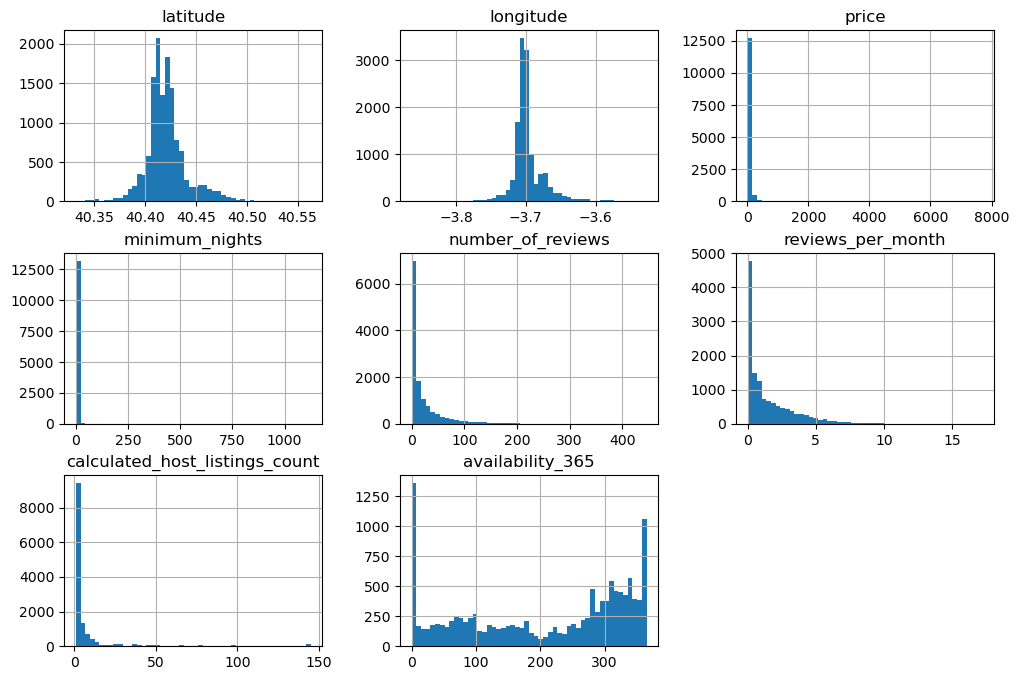

In [8]:
df.hist(bins=50, figsize=(12, 8))
plt.show()

Con estos gráficos confirmamos lo visto mediante `df.describe()`. Además, podemos obtener un poco más de información sobre la distribución de las variables, como:
- La latitud y longitud están sobre todo centradas en unas ubicaciones concretas. Su distribución se asemeja a una distribución normal.
- En cuanto a precio, confirmamos que la mayoría están por debajo de los 80 euros. El valor de 7700 euros parece ser un outlier.
- Confirmamos que la mayoría exigen una cantidad muy baja de noches mínimas. En este caso también, el valor máximo es de 1125, que parece ser un outlier. Esto tendría sentido teniendo en cuenta que son alquileres vacacionales.
- La mayoría de los alojamientos tienen un número de reseñas y promedio de reseñas mensuales bajo. Ambas variables parecen seguir la misma distribución, y la lógica nos dice que pueden estar correlacionadas porque se calculan a partir de un mismo total de reseñas.
- Confirmamos que la mayoría de los anfitriones poseen pocos listados.
- La distribución de la disponibilidad está distribuida de forma más o menos uniforme, con dos picos a los lados. Hay mayor frecuencia en alojamientos que están siempre disponibles (365) o nunca (0).

Analizaremos si hay correlación entre las variables numéricas:

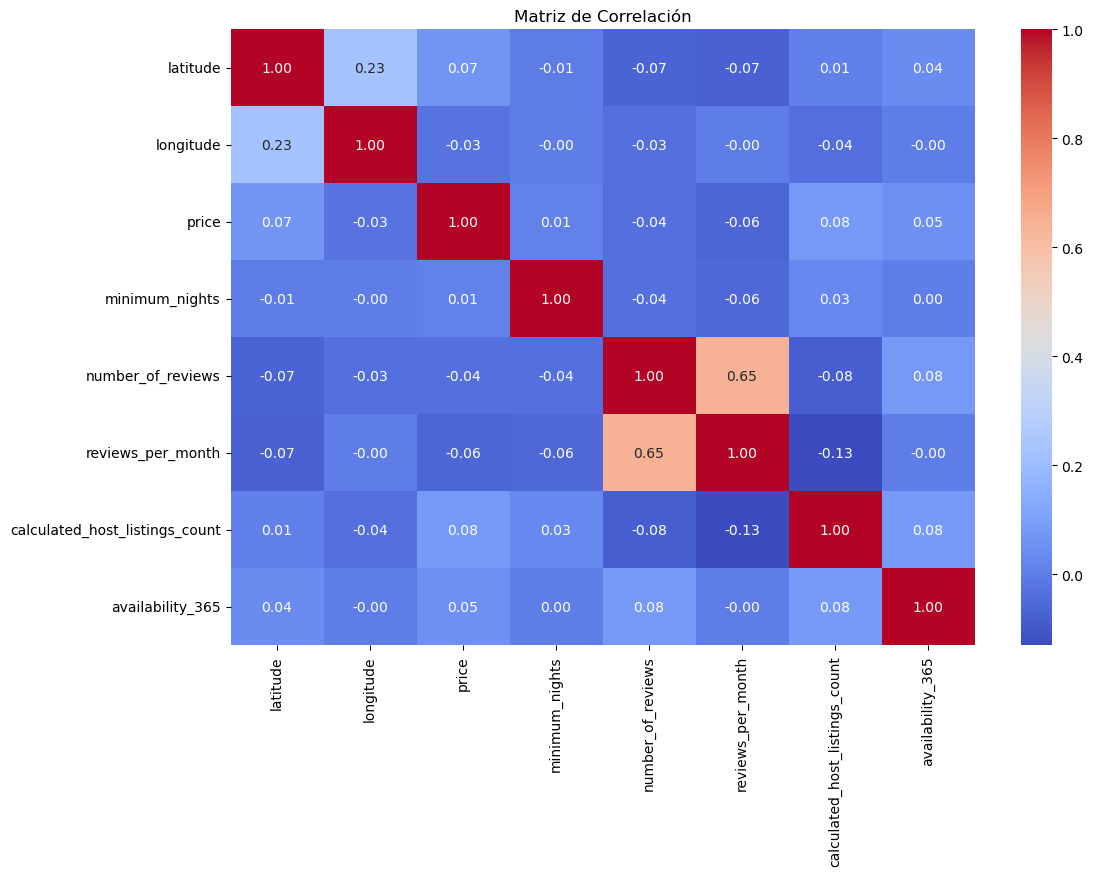

In [9]:
# Matriz de correlacion
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Concluimos que, efectivamente, hay una correlación entre el número de reseñas totales (`number_of_reviews`) y el promedio de reseñas mensuales (`reviews_per_month`).

Visualizaremos también la distribución de la ubicación en base a la latitud y longitud, y estableceremos `alpha=2` para ver la densidad de cada área:

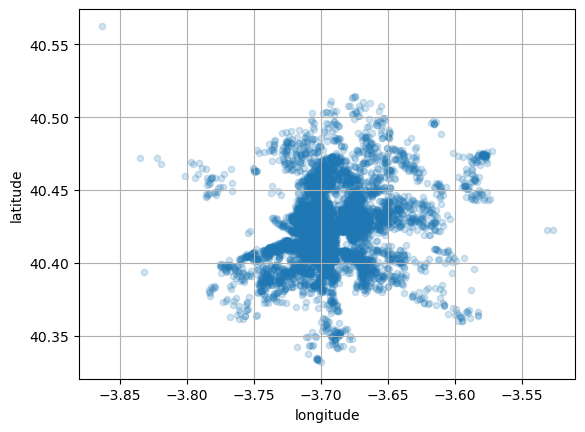

In [10]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

Vemos que el resultado se parece al mapa de Madrid, y que los áreas con más densidad están en el centro.

Ahora intentaremos ver si hay una correlación entre los precios y la ubicación, pintando los puntos según los precios:

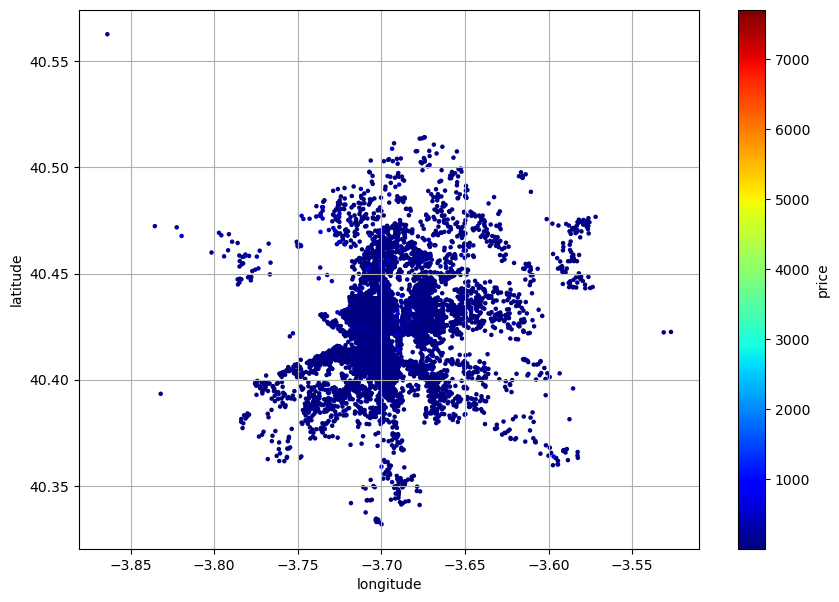

In [11]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
        c="price", cmap="jet", colorbar=True, s=5,
       legend=True, sharex=False, figsize=(10, 7))
plt.show()

En esta visualización no se ven conclusiones claras. Esto se debe a que el 75% de las propiedades tienen un precio inferior a 80 euros, lo que hace que casi todos los puntos que se ven sean de un color muy oscuro.

Si filtramos nuestro dataset para sólo mostrar aquellas entradas que tengan un precio inferior a 200 euros, obtenemos una mejor resolución en cuanto a los colores:

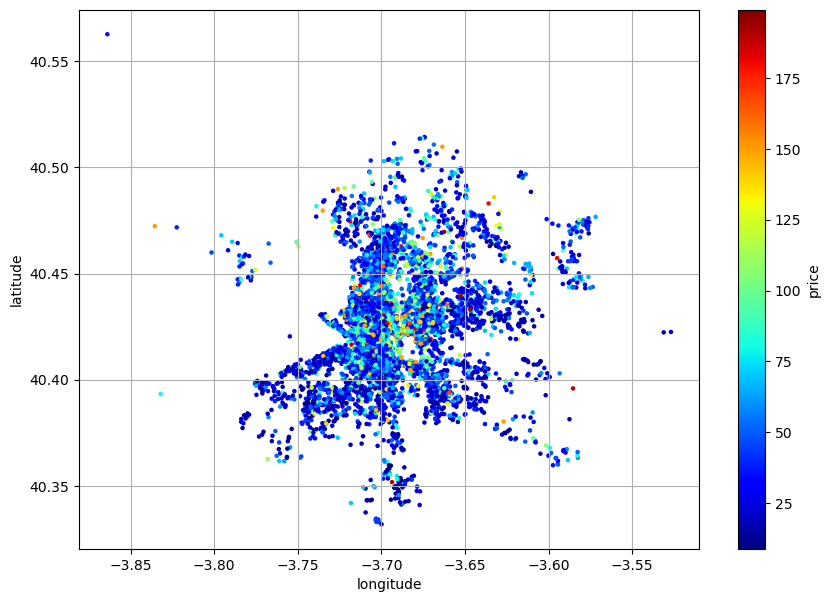

In [12]:
df_filtered = df[df["price"] < 200]
df_filtered.plot(kind="scatter", x="longitude", y="latitude", grid=True,
        c="price", cmap="jet", colorbar=True, s=5,
       legend=True, sharex=False, figsize=(10, 7))
plt.show()

En esta visualización se intuye que las propiedades del centro tienen precios más elevados.

### Análisis de Variables Categóricas

Analicemos ahora los valores de las variables categóricas. Realizaremos un conteo de cada categoría y miraremos el porcentaje total.

Comenzaremos con `neighbourhood_group`:

In [13]:
# Contar por neighbourhood_group y calcular el % total
count_neighbourhood_group = df["neighbourhood_group"].value_counts().reset_index()
count_neighbourhood_group.columns = ['neighbourhood_group', 'count']
count_neighbourhood_group['%'] = (count_neighbourhood_group['count'] / count_neighbourhood_group['count'].sum()) * 100
count_neighbourhood_group

,neighbourhood_group,count,%
0,Centro,6773,50.844531
1,Chamberí,960,7.206666
2,Salamanca,883,6.628631
3,Arganzuela,790,5.930486
4,Tetuán,463,3.475715
5,Moncloa - Aravaca,450,3.378125
6,Retiro,439,3.295548
7,Latina,379,2.845132
8,Chamartín,361,2.710007
9,Carabanchel,358,2.687486


Vemos que la mayoría de las viviendas están ubicadas en el centro.

A continuación analizaremos `neighbourhood`:

In [14]:
# Contar por neighbourhood y calcular el % total
count_neighbourhood = df["neighbourhood"].value_counts().reset_index()
count_neighbourhood.columns = ['neighbourhood', 'count']
count_neighbourhood['%'] = (count_neighbourhood['count'] / count_neighbourhood['count'].sum()) * 100
count_neighbourhood

,neighbourhood,count,%
0,Embajadores,1848,13.872832
1,Universidad,1363,10.231965
2,Palacio,1084,8.137527
3,Sol,942,7.071541
4,Justicia,788,5.915472
...,...,...,...
121,Rosas,4,0.030028
122,Hellín,4,0.030028
123,Cuatro Vientos,3,0.022521
124,Orcasitas,2,0.015014


En cuanto al análsis de los vecindarios, vemos que hay muchos vecindarios (126 en total). Esta variable `neighbourhood` está muy relacionada con la anterior `neighbourhood_group` y, a simple vista, puede parecer redundante. Sin embargo, nos aporta más detalle que el anterior, y de entrada, es interesante probar cómo actúan los modelos con ambas columnas.

También es interesante resaltar que las variables `latitude` y `longitude` representan la ubicación, y que pueden parecer solaparse también con estas variables `neighbourhood` y `neighbourhood_group`. Sin embargo, en este caso también exploraremos cómo actúan los modelos con todos estos datos antes de tomar alguna decisión de eliminación de variables.

Ahora analicemos `room_type`:

In [15]:
# Contar por room_type y calcular el % total
count_room_type = df["room_type"].value_counts().reset_index()
count_room_type.columns = ['room_type', 'count']
count_room_type['%'] = (count_room_type['count'] / count_room_type['count'].sum()) * 100
count_room_type

,room_type,count,%
0,Entire home/apt,7926,59.500038
1,Private room,5203,39.058629
2,Shared room,192,1.441333


`room_type`, es nuestra variable objetivo. En los resultados vemos que las clases están desbalanceadas, dado que la mayoría de las instancias son de apartamentos/casas enteras (`Entire home/apt`), y hay muy pocas que corresponden a habitaciones compartidas (`Shared room`). Teniendo en cuenta que los datos representan alquileres vacacionales, tiene sentido que la oferta de `Shared room` sea baja, dado que no es lo habitual alquilar una habitación compartida para vacaciones.

Este desbalanceo puede llevar que un modelo ignore las clases menos representadas, resultando en un rendimiento deficiente. Por lo tanto, tal y como el enunciado indica, consideraremos utilizar mecanismos de los propios algoritmos de clasificación para intentar contrarestar este problema.

## Preprocesamiento de Datos

En esta fase nos centraremos en limpiar, dividir y transformar el conjunto de datos, para obtener los datos de entrada necesarios para los modelos de Aprendizaje Automático.


### Eliminar Outliers

Eliminaremos los outliers máximos en las columnas `price` y `minimum_nights` detectadas en la fase de Estudio Estadístico para que los valores extremos no afecten negativamente al rendimiento del modelo:

In [16]:
df = df.drop(df['price'].idxmax())
df = df.drop(df['minimum_nights'].idxmax())
df.shape

(13319, 11)

No eliminaremos más outliers porque las demás variables no presentan desviaciones significativas según la información que tenemos y el conocimiento del dominio que disponemos.

### Dividir los datos en Conjunto de Entrenamiento y Test

Dividiremos los datos en conjunto de entrenamiento y test de manera que el conjunto de test sea un 20 % del total, tal y como lo solicita el enunciado. Para conservar una buena representación de las clases en esta división, haremos un muestreo estratificado basado en la columna `room_type`.

In [17]:
train_set, test_set = train_test_split(df, test_size = 0.2, stratify=df["room_type"], random_state = 0)

Comprobamos que efectivamente, las proporciones se mantienen en el `train_set` y `test_set`:

In [18]:
count_room_type_train = train_set["room_type"].value_counts().reset_index()
count_room_type_train.columns = ['room_type', 'count']
count_room_type_train['%'] = (count_room_type_train['count'] / count_room_type_train['count'].sum()) * 100
count_room_type_train

,room_type,count,%
0,Entire home/apt,6340,59.502581
1,Private room,4161,39.052088
2,Shared room,154,1.445331


In [19]:
count_room_type_test = test_set["room_type"].value_counts().reset_index()
count_room_type_test.columns = ['room_type', 'count']
count_room_type_test['%'] = (count_room_type_test['count'] / count_room_type_test['count'].sum()) * 100
count_room_type_test

,room_type,count,%
0,Entire home/apt,1585,59.496997
1,Private room,1041,39.076577
2,Shared room,38,1.426426


Dividimos los dataframes en `X` para variables (*features*) e `y` para la variable objetivo:

In [20]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'room_type'
y_train_set = train_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_train_set = train_set.drop(columns=['room_type'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'room_type'
y_test_set = test_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_test_set = test_set.drop(columns=['room_type'])

### Pipeline de Preprocesamiento de Datos

El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: algunos algoritmos de Naive Bayes, como el MultinomialNB, no pueden trabajar con datos negativos. Por esta razón, se descarta el StandardScaler y utilizaremos el MinMaxScaler para asegurarnos de que el escalado se realice únicamente en rangos positivos.

La variable objetivo `room_type` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [21]:
num_attribs = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("minmax_scaler", MinMaxScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

Ajustamos el *preprocessing pipeline* a las características de `X_train_set` y luego transformamos tanto `X_train_set` como `X_test_set` aplicando las transformaciones definidas:

In [22]:
# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Es importante tener en cuenta que OneHotEncoder genera una gran cantidad de columnas o dimensiones, y esto incrementa el número de instancias necesarias para obtener un entrenamiento confiable. Estas son las columnas que tienen nuestros datos transformados:

In [23]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__latitude', 'num__longitude', 'num__price',
       'num__minimum_nights', 'num__number_of_reviews',
       'num__reviews_per_month', 'num__calculated_host_listings_count',
       'num__availability_365', 'cat__neighbourhood_group_Arganzuela',
       'cat__neighbourhood_group_Barajas',
       'cat__neighbourhood_group_Carabanchel',
       'cat__neighbourhood_group_Centro',
       'cat__neighbourhood_group_Chamartín',
       'cat__neighbourhood_group_Chamberí',
       'cat__neighbourhood_group_Ciudad Lineal',
       'cat__neighbourhood_group_Fuencarral - El Pardo',
       'cat__neighbourhood_group_Hortaleza',
       'cat__neighbourhood_group_Latina',
       'cat__neighbourhood_group_Moncloa - Aravaca',
       'cat__neighbourhood_group_Moratalaz',
       'cat__neighbourhood_group_Puente de Vallecas',
       'cat__neighbourhood_group_Retiro',
       'cat__neighbourhood_group_Salamanca',
       'cat__neighbourhood_group_San Blas - Canillejas',
       'cat__neighbourhood_group_Te

Revisamos que la transformación se ha realizado según lo esperado:

In [24]:
X_train_set_preprocessed

<10655x155 sparse matrix of type '<class 'numpy.float64'>'
	with 92349 stored elements in Compressed Sparse Row format>

In [25]:
X_train_set_preprocessed[:2].toarray()

array([[0.53771577, 0.50558961, 0.01370779, 0.01098901, 0.00224215,
        0.01045904, 0.19444444, 0.3369863 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        , 0.        , 0.        , 0.  

## Experimentos

En esta sección se describen los experimentos realizados para evaluar y optimizar el rendimiento de los algoritmos de clasificación. 


### Experimento 1 - Fase de Experimentación y Selección de Modelo

En el primer experimento se han probado los algoritmos de Naive Bayes, K-Nearest Neighbors (K-NN) y árboles de decisión. El objetivo ha sido identificar los algoritmos que mejor trabajan con este conjunto de datos, evaluando los modelos midiendo la exactitud (accuracy) con validación cruzada, y utilizando los parámetros por defecto de los métodos (salvo parámetros que puedan mejorar el desbalanceo, tal y como lo solicita el enunciado).

Debido a que existen varios algoritmos de Naive Bayes, en esta fase exploratoria se han probado varios de ellos y analizado el rendimiento de cada uno.

Para hacer el código más legible, crearemos el método de impresión de resultados:

In [26]:
def print_results(accuracies):
    print(f"Array de Precisiones = {accuracies}\n")
    
    # Media
    mean_accuracy = np.mean(accuracies)
    print(f"Precisión Media: {mean_accuracy}\n")
    
    # Desviación estándar
    std_deviation = np.std(accuracies)
    print(f"Desviación estándar: {std_deviation}")

#### Gaussian Naive Bayes

El Gaussian Naive Bayes asume que las características de entrada siguen una distribución normal (gaussiana).

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [27]:
# Crear una instancia del clasificador gaussiano Naive Bayes
gnb_classifier = GaussianNB()

# Aplicar el cross_val_score
gnb_accuracies = cross_val_score(gnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(gnb_accuracies)

Array de Precisiones = [0.16228893 0.14915572 0.16604128 0.14446529 0.14821764 0.14366197
 0.15586854 0.17934272 0.16807512 0.14178404]

Precisión Media: 0.15589012499009064

Desviación estándar: 0.011940456310349217


El rendimento general del modelo parece ser bastante malo, con un promedio de la precisión del 0.156 (15.6%). Hay cierta variabilidad en los resultados de la precisión, tal y como se puede ver en la desviación estandar de 0.011.

Puede haber varios factores afectando al rendimiento. La principal podría ser que GaussianNB asume que las características siguen una distribución gaussiana (normal), sin embargo, en el Estudio Estadístico Inicial hemos visto que nuestras características no siguen dicha distribución. Por otra parte, Naive Bayes requiere que las características sean independientes entre sí, y en nuestro caso hemos detectado ciertas correlaciones y solapamientos. Finalmente, el desequilibrio entre clases también podría afectar.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [28]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
gnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = gnb_classifier.predict(X_test_set_preprocessed.toarray())

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Private room']
 ['Shared room' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Shared room']
 ['Shared room' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Shared room' 'Private room']
 ['Shared room' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']]


Al visualizar algunas de las etiquetas predichas junto a los valores reales, vemos que nuestro modelo muchas veces predice `Shared room` (primera columna) cuando en realidad corresponde a otras etiquetas.

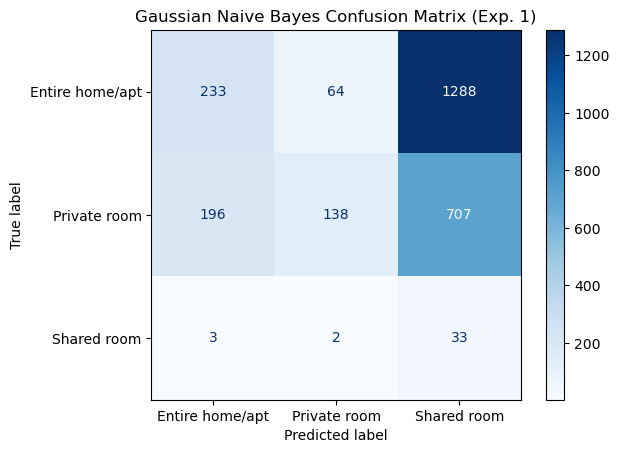

Accuracy: 0.15165165165165165


In [29]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gnb_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Gaussian Naive Bayes Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

Matriz de Confusión: El modelo sólo clasifica bien las `Shared room`. Por lo general, ha confundido `Entire home/apt` y `Private room` como `Shared room`. Parece que las características de `Shared room` no discriminan lo suficiente para distinguir entre las otras dos clases.

La puntuación de la precisión es 0.1577. Esto significa que el modelo clasifica correctamente el 15.77% de las instancias en el conjunto de datos. Es una puntuación muy baja.

#### Multinomial Naive Bayes

El Multinomial Naive Bayes asume que las características de entrada siguen una distribución multinomial.

In [30]:
mnb_classifier = MultinomialNB()

# Aplicar el cross_val_score
mnb_accuracies = cross_val_score(mnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(mnb_accuracies)

Array de Precisiones = [0.63508443 0.65853659 0.6369606  0.63414634 0.68198874 0.6657277
 0.6657277  0.66760563 0.66384977 0.64413146]

Precisión Media: 0.6553758951457338

Desviación estándar: 0.01575412462388547


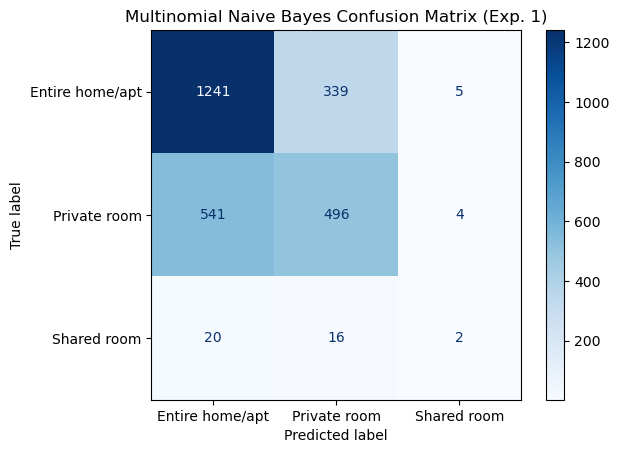

Accuracy: 0.6527777777777778


In [31]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
mnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = mnb_classifier.predict(X_test_set_preprocessed.toarray())

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mnb_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Multinomial Naive Bayes Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

El resultado es mejor que Gaussian Naive Bayes. Sin embargo, la matriz de confusión nos muestra que está sesgado hacia `Entire home/apt`, ya que podemos ver que clasifica como tal la mayoría de los `Private room` y `Shared room`.

#### Complement Naive Bayes

También asume que las características de entrada siguen una distribución multinomial, pero es adecuado cuando las muestras no están balanceadas.

In [32]:
cnb_classifier = ComplementNB()

# Aplicar el cross_val_score
cnb_accuracies = cross_val_score(cnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(cnb_accuracies)

Array de Precisiones = [0.61257036 0.6369606  0.62570356 0.61726079 0.65009381 0.65352113
 0.6629108  0.64976526 0.64976526 0.64694836]

Precisión Media: 0.640549991632094

Desviación estándar: 0.015901788958700386


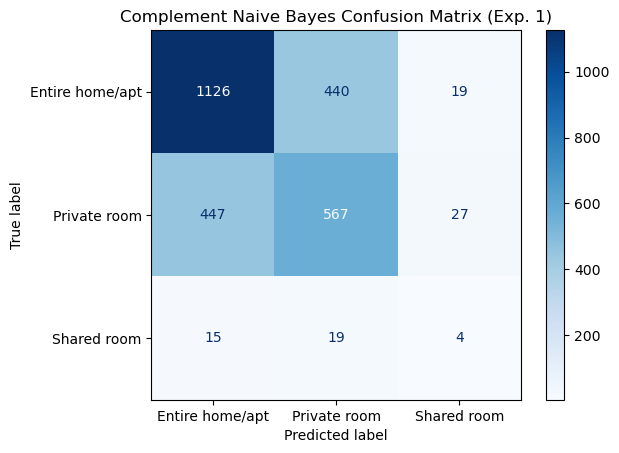

Accuracy: 0.637012012012012


In [33]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
cnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = cnb_classifier.predict(X_test_set_preprocessed.toarray())

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cnb_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Complement Naive Bayes Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

El resultado de la precisión es parecida al Multinomial Naive Bayes (aproximadamente un 2% más baja). En la matriz de confusión vemos que el modelo sigue estando sesgado hacia `Entire home/apt`, sin embargo, dicho sesgo es menor, ya que ahora clasifica mejor las `Private room`-s, por lo que podemos decir que el entrenamiento está mejor balanceado. No clasifica bien las `Shared room`.

#### Bernoulli Naive Bayes

El Bernoulli Naive Bayes asume que las características de entrada siguen una distribución de Bernoulli.

In [34]:
bnb_classifier = BernoulliNB()

# Aplicar el cross_val_score
bnb_accuracies = cross_val_score(bnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(bnb_accuracies)

Array de Precisiones = [0.66604128 0.66135084 0.66604128 0.66228893 0.69136961 0.67511737
 0.69859155 0.68920188 0.69107981 0.6713615 ]

Precisión Media: 0.6772444045133842

Desviación estándar: 0.013251588725951396


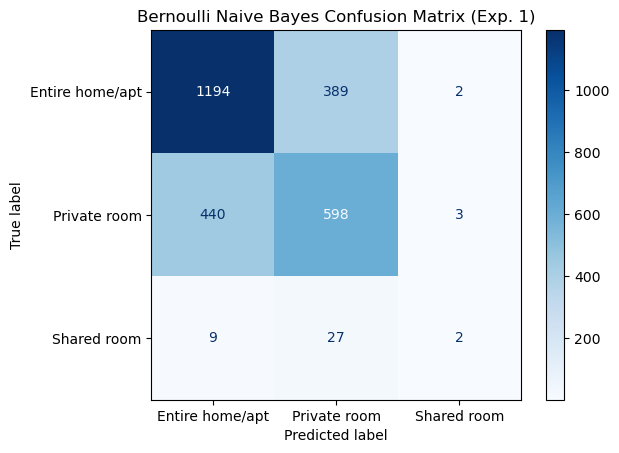

Accuracy: 0.6734234234234234


In [35]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
bnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = bnb_classifier.predict(X_test_set_preprocessed.toarray())

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bnb_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Bernoulli Naive Bayes Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

El modelo tiende a estar sesgado hacia `Entire home/apt`, que es la instancia que más representación tiene en los datos. Muestra malas tasas de acierto para `Private room` (acierta poco más que la mitad), aunque son mejores que las anteriores. Y sigue sin poder clasificar correctamente las `Shared room`.

La puntuación de la precisión es la más alta de todas las variantes de Naive Bayes testeadas.

#### K-NN

K-Nearest Neighbors (K-NN) clasifica una instancia basándose en la mayoría de las etiquetas de sus k vecinos más cercanos.

Para esta primera prueba, estableceremos el hiperparámetro `n_neighbors = 5`. Sin embargo, más adelante en el experimento número 2 haremos la búsqueda del valor ideal.

Además, cambiaremos el hiperparámetro `weights` para compensar el desbalanceo de clases, tal y como lo indica el enunciado. El hiperparámetro `weights` por defecto viene con el valor `uniform`, lo cual significa que realiza ponderaciones uniformes, es decir, todos los puntos de cada vecindario se ponderan por igual. Sin embargo, seleccionaremos el valor `distance`, que implica ponderar los puntos por la inversa de su distancia. En este caso, los vecinos más cercanos de un punto de consulta tendrán mayor influencia que los vecinos más alejados. Esto es útil para mejorar la clasificación de categorías con poca respresentación, como en este caso que tenemos un desbalanceo de clases.

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [36]:
# Crear una instancia de KNeighborsClassifier con 5 vecinos
knn_classifier = KNeighborsClassifier(n_neighbors = 5)

# Aplicar el cross_val_score
knn_accuracies = cross_val_score(knn_classifier, X_train_set_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(knn_accuracies)

Array de Precisiones = [0.70731707 0.69981238 0.69699812 0.69512195 0.72138837 0.70892019
 0.72394366 0.72206573 0.72957746 0.70516432]

Precisión Media: 0.7110309260189027

Desviación estándar: 0.011697401509386479


Los resultados muestran una precisión media de 0.719 (71.9%), mejor que las obtenidas con Naive Bayes, con una desviación estándar del 0.011 (hay cierta variación, pero es poca la inconsistencia). Conviene experimentar con la optimización de hiperparámetros (búsqueda de la k óptima) y ver si mejora la precisión.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [37]:
# Ajustar el modelo KNN a los datos de entrenamiento (X_train_set_preprocessed: características, y_train_set: etiquetas de destino)
knn_classifier.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = knn_classifier.predict(X_test_set_preprocessed)

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Shared room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']]


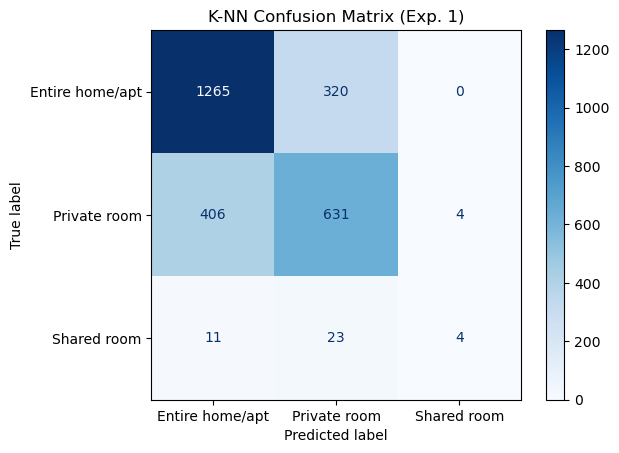

Accuracy: 0.7132132132132132


In [38]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('K-NN Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

El modelo tiende a estar sesgado hacia `Entire home/apt`, que es la instancia que más representación tiene en los datos. Muestra tasas de acierto no muy altas para `Private room` (acierta alrededor del 63% solo), aunque son un poco mejores que el Bernoulli Naive Bayes. Y tiene tasas de acierto muy malas para `Shared room`, dado que rara vez clasifica una instancia como `Shared room`.

La precisión mejora los anteriores resultados de Naive Bayes.

#### Árboles de Decisión

Un árbol de decisión es una estructura similar a un diagrama de flujo en la que cada nodo interno representa una test sobre un atributo, cada rama representa el resultado del test y cada nodo hoja representa una etiqueta de clase.

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

El enunciado requiere la utilización de los parámetros de los constructores para balancear. En la inicialización del clasificador `DecisionTreeClassifier`, he utilizado el parámetro `class_weight='balanced'` para manejar conjuntos de datos desbalanceados. Este parámetro ajusta automáticamente el peso de cada clase inversamente proporcional a su frecuencia. De este modo, se reducirá el sesgo hacia las clases mayoritarias.

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [39]:
# Crear un objeto clasificador de árbol de decisión
dt_classifier = DecisionTreeClassifier(random_state = 0, class_weight='balanced')

# Aplicar el cross_val_score
dt_accuracies = cross_val_score(dt_classifier, X_train_set_preprocessed, y_train_set, scoring="accuracy", cv=10)
print_results(dt_accuracies)

Array de Precisiones = [0.84896811 0.85084428 0.84709193 0.86491557 0.8424015  0.85352113
 0.85821596 0.8629108  0.8685446  0.84788732]

Precisión Media: 0.8545301200574302

Desviación estándar: 0.008247307313322476


Los resultados muestran una precisión media de 0.855 (85.5%), mejor que las obtenidas con Naive Bayes y K-NN, con una desviación estándar del 0.008, siendo también la más baja obtenida hasta ahora. Es un resultado parece razonablemente preciso y consistente.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [40]:
# Ajustar el clasificador a los datos de entrenamiento
dt_classifier.fit(X_train_set_preprocessed, y_train_set)

# Predecir las etiquetas objetivo para el conjunto de prueba
y_pred = dt_classifier.predict(X_test_set_preprocessed)

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Shared room' 'Shared room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']]


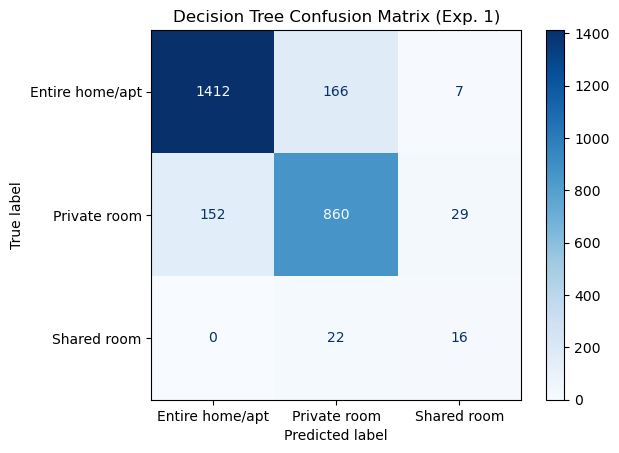

Accuracy: 0.8588588588588588


In [41]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set, y_pred)

# Dibujar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix (Exp. 1)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

El modelo tiende a ofrecer una muy alta tasa de acierto para las `Entire home/apt` y una alta tasa de acierto también para los `Private room`. Ya no se ve tanta confusión ni sesgo hacia `Entire home/apt` como con los modelos anteriores. Sin embargo, no clasifica bien las `Shared room`, confundiéndolas a veces con `Private room`-s.

La puntuación de la precisión en el conjunto de test es 0.8588, lo cual mejora los anteriores resultados de Naive Bayes y K-NN.

**3. Visualización del Árbol Obtenido (Explicabilidad)**

In [42]:
feature_names_list = preprocessing.get_feature_names_out().tolist()
class_names_list = dt_classifier.classes_.tolist()

# Genera un archivo .dot que representa el árbol de decisiones
export_graphviz(
     dt_classifier,
     out_file="decision_tree.dot",
     feature_names=feature_names_list,
     class_names=class_names_list,
     rounded=True,
     filled=True
 )

# Lee y visualiza el archivo .dot generado para inspeccionar el árbol de decisiones
Source.from_file("decision_tree.dot")

La magnitud del árbol obtenido es bastante grande y esto hace que sea difícil de interpretar.

Vamos a explorar los hiperparámetros que ha utilizado nuestro modelo para construir el árbol:

In [43]:
print("Valor de max_depth aplicado:", dt_classifier.tree_.max_depth)
print("Número de max_leaf_nodes aplicado:", dt_classifier.get_n_leaves())
print("Valor de min_samples_split aplicado:", dt_classifier.min_samples_split)

Valor de max_depth aplicado: 38
Número de max_leaf_nodes aplicado: 1278
Valor de min_samples_split aplicado: 2


Estos hiperparámetros explican la complejidad de nuestro árbol:

- `max_depth`: Profundidad máxima del árbol. En este caso, como no hemos establecido un parámetro de entrada (`None`), los nodos se han expandido mucho, hasta que todas las hojas sean puras o hasta que todas las hojas contengan menos muestras que `min_samples_split`, llegando hasta 38.
- `max_leaf_nodes`: limita el número máximo de nodos hoja en un árbol. En este caso, como no hemos establecido un parámetro de entrada (`None`), no se ha limitado el número de nodos hojam, llegando hasta los 1278.
- `min_samples_split`: número mínimo de muestras necesarias para dividir un nodo interno. Por defecto se establece a 2.

Para tener algo más de explicabilidad, podemos obtener la importancia de las features y evaluar qué características tienen más peso en la toma de decisiones:

In [44]:
# Asociar cada importancia con el nombre de su característica
feature_importances = pd.DataFrame({'feature': feature_names_list, 'importance': dt_classifier.feature_importances_})

# Mostrar el resultado ordenado
print(feature_importances.sort_values(by='importance', ascending=False))

                              feature  importance
2                          num__price    0.418727
7               num__availability_365    0.098308
0                       num__latitude    0.084456
1                      num__longitude    0.060231
5              num__reviews_per_month    0.058894
..                                ...         ...
116     cat__neighbourhood_Peñagrande    0.000000
61         cat__neighbourhood_Chopera    0.000000
118  cat__neighbourhood_Pinar del Rey    0.000000
59        cat__neighbourhood_Castilla    0.000000
154          cat__neighbourhood_Zofío    0.000000

[155 rows x 2 columns]


Vemos que, sobre todo, el precio tiene mucho peso en la decisión, seguido por otras variables como la disponibilidad y la ubicación (en cuanto a latitud y longitud).

#### Resumen y Conclusiones del Experimento 1

El objetivo de este experimento ha sido realizar un primer sondeo con los diferentes modelos y analizar cómo se comporta cada uno de ellos sobre el mismo dataset preprocesado. Estos han sido los resultados obtenidos:


| Modelo                     | Precisión Media  | Desviación Estándar | Comentarios                                                                                                                                                                                |
|----------------------------|------------------|----------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Gaussian Naive Bayes       | 0.1559           | 0.0119               | Precisión baja, probablemente porque las características no siguen una distribución gaussiana. Sesgado excesivamente hacia `Shared Room` (mal), no discrimina bien.                     |
| Multinomial Naive Bayes    | 0.6554           | 0.0158               | Precisión baja, aunque mejor. Sesgado hacia `Entire home/apt`, malas tasas de acierto para las demás clases.      |
| Complement Naive Bayes     | 0.6405           | 0.0159               | Precisión parecida al multinomial, pese a ser más apropiado para datasets desbalanceados. Sigue sesgado hacia `Entire home/apt` aunque menos, y tiene mejor tasa de acierto para `Private room` que la anterior. No acierta `Shared room`-s.                |
| Bernoulli Naive Bayes      | 0.6772           | 0.0133               | El mejor de los Naive Bayes, quizás porque las variables categóricas en forma de binarios le permiten modelar mejor el conjunto de datos. Aun así, sigue siendo una precisión baja. Tiende a estar sesgado hacia `Entire home/apt` aunque menos que las anteriores. No acierta `Shared room`-s.                                                      |
| K-NN                       | 0.7185           | 0.0108               | Mejor que cualquier Naive Bayes. Sesgado hacia `Entire home/apt`, pero no tanto como Naive Bayes.                                                                                                      |
| Árboles de Decisión        | 0.8545           | 0.0082               | Mejor precisión y variabilidad baja. Mejor matriz de confusión, clasificando bien `Entire home/apt` y `Private room`. 45% de acierto para `Shared room`. Árbol muy complejo, quizás sobreajustado al dataset. |

Tras este primer experimento, concluimos que sería razonable descartar Naive Bayes para este problema, dada su baja precisión y sus tendencias a clasificaciones incorrectas y sesgos. Además, Naive Bayes se utiliza cuando se cumple la suposición de independencia entre características y hay una distribución específica de los datos (como la gaussiana o multinomial). Sin embargo, nuestro dataset no parece cumplir con estas características.

En los siguientes experimentos sólo realizaremos pruebas con K-NN y Árboles de Decisión.

### Experimento 2 - Preprocesamiento con StandardScaler

Como vamos a seguir haciendo pruebas con K-NN y Árboles de Decisión, y estos modelos pueden manejar valores negativos, y además se ha visto que la variable precio tiene peso en la decisión, he decidido volver a ejecutar la etapa de preproesamiento de datos pero esta vez utilizando `StandardScaler`. 

Por lo tanto, el objetivo de este segundo experimento es ver si K-NN y los Árboles de Decisión mejoran con `StandardScaler`, antes de pasar al ajuste de los hiperparámetros.

#### Pipeline de Preprocesamiento de Datos

In [45]:
num_attribs = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Revisamos que la transformación se ha realizado según lo esperado:

In [46]:
X_train_set_preprocessed

<10655x155 sparse matrix of type '<class 'numpy.float64'>'
	with 106550 stored elements in Compressed Sparse Row format>

In [47]:
X_train_set_preprocessed[:2].toarray()

array([[ 1.74614858,  0.16346946, -0.23798267,  0.2468434 , -0.56682293,
        -0.72360467,  1.08206011, -0.65924589,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

#### K-NN

In [48]:
# Crear una instancia de KNeighborsClassifier con 5 vecinos (es el valor por defecto)
knn_classifier = KNeighborsClassifier(n_neighbors = 5, weights="distance")

# Aplicar el cross_val_score
knn_accuracies = cross_val_score(knn_classifier, X_train_set_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(knn_accuracies)

Array de Precisiones = [0.80487805 0.81894934 0.81332083 0.81144465 0.8217636  0.78779343
 0.81314554 0.81971831 0.81502347 0.81877934]

Precisión Media: 0.812481656669221

Desviación estándar: 0.009465834183014022


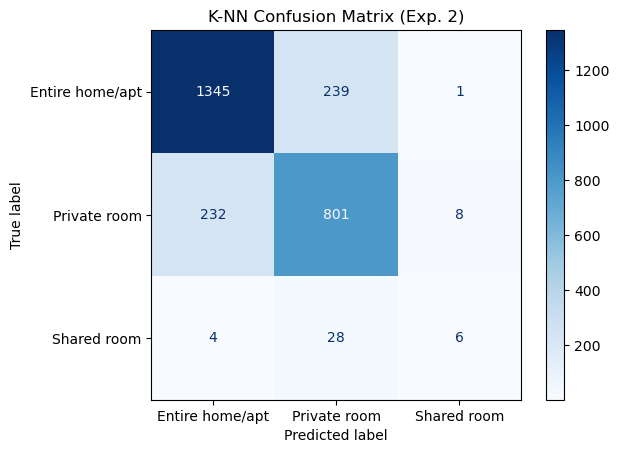

Accuracy: 0.8078078078078078


In [49]:
# Ajustar y predecir
knn_classifier.fit(X_train_set_preprocessed, y_train_set.values.ravel())
y_pred = knn_classifier.predict(X_test_set_preprocessed)

# Matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('K-NN Confusion Matrix (Exp. 2)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

La puntuación de la precisión ha mejorado y el sesgo hacia `Entire home/apt` ha disminuido. Aún así, el modelo sigue clasificando mal los `Shared room`.

#### Árboles de Decisión

In [50]:
# Crear un objeto clasificador de árbol de decisión
dt_classifier = DecisionTreeClassifier(random_state = 0, class_weight='balanced')

# Aplicar el cross_val_score
dt_accuracies = cross_val_score(dt_classifier, X_train_set_preprocessed, y_train_set, scoring="accuracy", cv=10)
print_results(dt_accuracies)

Array de Precisiones = [0.85272045 0.84896811 0.85834897 0.85741088 0.84709193 0.86103286
 0.85633803 0.8600939  0.8629108  0.84694836]

Precisión Media: 0.855186428137304

Desviación estándar: 0.005588749895652439


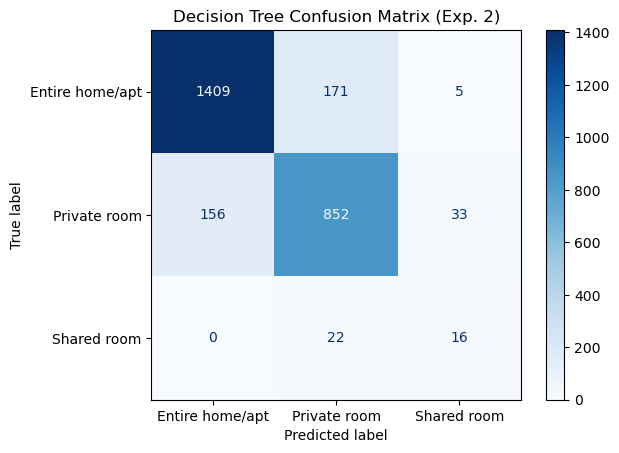

Accuracy: 0.8547297297297297
Valor de max_depth aplicado: 34
Número de max_leaf_nodes aplicado: 1275
Valor de min_samples_split aplicado: 2


In [51]:
# Ajustar y predecir
dt_classifier.fit(X_train_set_preprocessed, y_train_set)
y_pred = dt_classifier.predict(X_test_set_preprocessed)

# Matriz de confusión
cm = confusion_matrix(y_test_set, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix (Exp. 2)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

print("Valor de max_depth aplicado:", dt_classifier.tree_.max_depth)
print("Número de max_leaf_nodes aplicado:", dt_classifier.get_n_leaves())
print("Valor de min_samples_split aplicado:", dt_classifier.min_samples_split)

Los resultados de la matriz de confusión son muy parecidos al anterior obtenido con `MinMaxScaler` en el Experimento 1. Las dimensiones del árbol siguen siendo muy grandes.

#### Resumen y Conclusiones del Experimento 2

El uso de `StandardScaler` mejora las métricas del K-NN, dado que homogeneiza la escala de las características y mejora el cálculo de la distancia. Para árboles de decisión no es tan relevante el escalador, ya que el modelo no depende de la escala de las características. En el caso de los árboles de decisión, hemos obtenido un resultado de precisión similar al anterior.

Viendo la mejora en el K-NN, y que no afecta a los árboles de decisión, decidimos mantener el StandardScaler en los siguientes experimentos.

### Expermiento 3 - Afinar Hiperparámetros

El objetivo de este experimento es realizar la afinación de hiperparámetros para KNN y Árboles de decisión empleando `GridSearchCV`, tal y como el enunciado lo solicita.

Según el enunciado, Naive Bayes no tiene hiperparámetros que afinar, y es por ello que no hemos incluido en este experimento, además de que los resultados obtenidos con este algoritmo no han sido buenos.

#### K-NN

Para KNN buscaremos el valor óptimo de K utilizando `GridSearchCV` y teniendo en cuenta que:
- El valor de *k* no puede exceder el número de filas de entrenamiento.
- El valor de *k* debe ser un número impar (para evitar situaciones en las que haya un empate entre las clases).
- El valor de *k* no debe ser un múltiplo del número de clases (para evitar empates).

In [52]:
# Definir el rango de valores para k
param_grid = {'n_neighbors': [k for k in range(1, 250) if k % 2 != 0 and k % 3 != 0]}

# Crear una instancia de KNeighborsClassifier
knn = KNeighborsClassifier()

# Configurar GridSearchCV y ajustar a los datos
grid_search = GridSearchCV(knn, param_grid, scoring='accuracy', cv=10)
grid_search.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Obtener el mejor valor de k
optimal_k = grid_search.best_params_['n_neighbors']
print(f"El número óptimo de vecinos es {optimal_k}")

El número óptimo de vecinos es 5


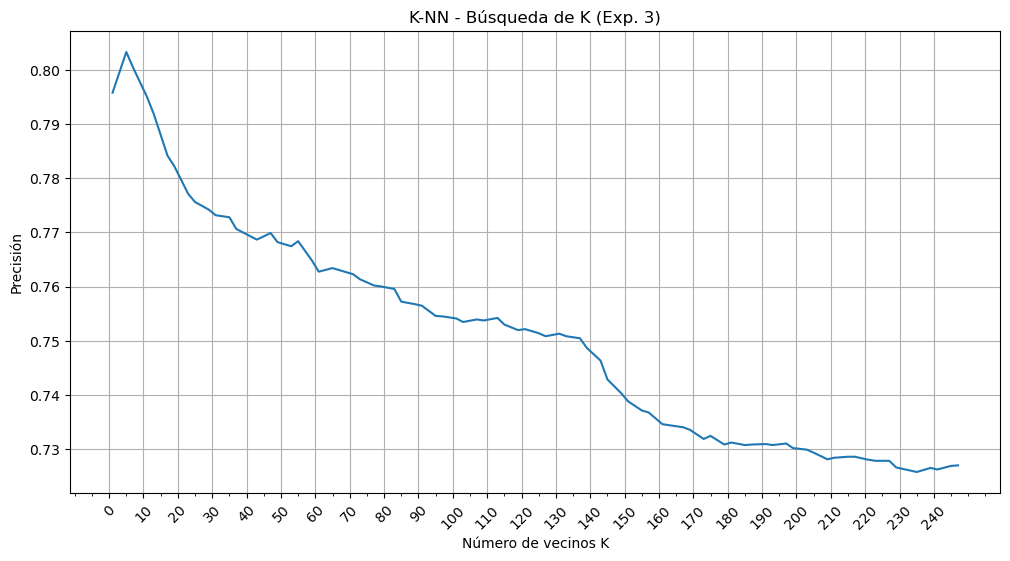

In [53]:
results = grid_search.cv_results_

# Extraer los valores de k y sus respectivas precisiones
ks = results['param_n_neighbors'].data
cv_scores = results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(ks, cv_scores)
plt.xlabel('Número de vecinos K')
plt.ylabel('Precisión')
plt.title('K-NN - Búsqueda de K (Exp. 3)')
plt.xticks(range(0, int(max(ks)) + 1, 10), rotation=45)
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(5))
plt.grid(True)
plt.show()

El número óptimo de vecinos es el número en el que se maximiza la precisión. En este caso es 5, y coincide con el valor que hemos utilizado en nuestras pruebas iniciales.

#### Árboles de Decisión

Para el árbol de decisión, realizaremos la afinación de hiperparámetros empleando `GridSearchCV` y variando:

- `max_leaf_nodes` entre 2 y 50 ambos inclusive
- `min_samples_split` entre 2 y 6 ambos inclusive
- `max_depth` entre 1 y 20 ambos inclusive

In [54]:
# Definir el rango de parámetros
param_grid = {
    'max_leaf_nodes': list(range(2, 51)),
    'min_samples_split': list(range(2, 7)),
    'max_depth': list(range(1, 21))
}

# Crear una instancia de DecisionTreeClassifier
decisionTree = DecisionTreeClassifier(random_state = 0, class_weight='balanced')

# Configurar GridSearchCV y ajustar a los datos
grid_search = GridSearchCV(decisionTree, param_grid, scoring='accuracy', cv=10)
grid_search.fit(X_train_set_preprocessed, y_train_set)

# Mejores parámetros encontrados
print(f"Mejores valores para los hiperparámetros: {grid_search.best_params_}")
print(f"Accuracy: {grid_search.best_score_}")

Mejores valores para los hiperparámetros: {'max_depth': 2, 'max_leaf_nodes': 3, 'min_samples_split': 2}
Accuracy: 0.8389466127597354


C:\Users\maial\.conda\envs\unedenv\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


En este apartado hemos optimizado los hiperparámetros utilizando unos rangos preestablecidos, limitando el crecimiento del árbol. Si lo comparamos con el árbol obtenido en anteriores experimentos, vemos que los experimentos 1 y 2 logran una precisión más alta. Sin embargo, este modelo es más sencillo y está optimizado, logrando también una precisión media buena de 0.8389.

Ahora entrenaremos un clasificador de árbol de decisión con los mejores hiperparámetros y analizaremos los resultados:

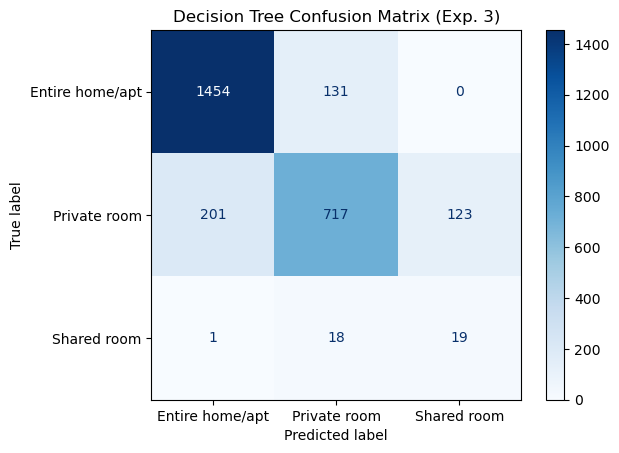

Accuracy: 0.8220720720720721


In [55]:
# Crear un objeto clasificador de árbol de decisión con los hiperparámetros
dt_classifier_v2 = DecisionTreeClassifier(
    random_state=0,
    class_weight='balanced',
    max_depth=2,
    max_leaf_nodes=3,
    min_samples_split=2
)

# Ajustar y predecir
dt_classifier_v2.fit(X_train_set_preprocessed, y_train_set)
y_pred = dt_classifier_v2.predict(X_test_set_preprocessed)

# Matriz de confusión
cm = confusion_matrix(y_test_set, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier_v2.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix (Exp. 3)')
plt.show()

# Precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

Visualizar el árbol:

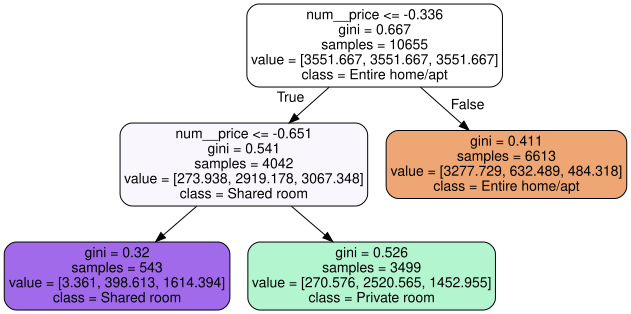

In [56]:
feature_names_list = preprocessing.get_feature_names_out().tolist()
class_names_list = dt_classifier_v2.classes_.tolist()

# Genera un archivo .dot que representa el árbol de decisiones
export_graphviz(
     dt_classifier_v2,
     out_file="decision_tree.dot",
     feature_names=feature_names_list,
     class_names=class_names_list,
     rounded=True,
     filled=True
 )

# Lee y visualiza el archivo .dot generado para inspeccionar el árbol de decisiones
Source.from_file("decision_tree.dot")

Tal y como vemos, este árbol contiene los hiperparámetros establecidos:
- `'max_depth': 2`: Tiene una profundidad de 2
- `'max_leaf_nodes': 3`: Contiene 3 nodos hoja
-  `'min_samples_split': 2`: Los nodos internos se dividen en 2 muestras.

Tras la visualización del árbol podemos ver que el atributo que utiliza para realizar la clasificación es el precio, clasificando como `Entire home/apt` aquellos de mayor precio, seguidos por `Private room` y finalmente siendo clasificados como `Shared room` las más baratas.

In [57]:
# Asociar cada importancia con el nombre de su característica
feature_importances = pd.DataFrame({'feature': feature_names_list, 'importance': dt_classifier_v2.feature_importances_})

# Mostrar el resultado ordenado
print(feature_importances.sort_values(by='importance', ascending=False))

                                            feature  importance
2                                        num__price         1.0
0                                     num__latitude         0.0
106                       cat__neighbourhood_Opañel         0.0
99                    cat__neighbourhood_Marroquina         0.0
100                  cat__neighbourhood_Media Legua         0.0
..                                              ...         ...
53                    cat__neighbourhood_Canillejas         0.0
54                 cat__neighbourhood_Casa de Campo         0.0
55    cat__neighbourhood_Casco Histórico de Barajas         0.0
56   cat__neighbourhood_Casco Histórico de Vallecas         0.0
154                        cat__neighbourhood_Zofío         0.0

[155 rows x 2 columns]


Al visualizar la importancia de cada atributo también vemos que es el precio el único que ha utilizado.

#### Resumen y Conclusiones del Experimento 3

El objetivo de este experimento ha sido ajustar los hiperparámetros según lo solicitado en el enunciado. Estos son los resultados obtenidos:

- **KNN:** El número óptimo de k es 5, y coincide con el utilizado en el Experimento 1.
- **Árboles de Decisión:** los rangos de partida para los hiperparámetros corresponden a un árbol más sencillo. Por lo tanto, tras la optimización, hemos conseguido el resultado `{'max_depth': 2, 'max_leaf_nodes': 3, 'min_samples_split': 2}`, obteniendo un modelo más sencillo, con buena precisión (0.8389), aunque los experimentos previos lograron una precisión ligeramente superior. Este nuevo modelo aporta mejor explicabilidad que los anteriores, y hemos concluido que el precio es definitivamente el atributo de gran relevancia.

### Experimento 4 - Reducción de la Dimensionalidad

Este último experimento es de carácter exploratorio, y es un extra al enunciado de la práctica. Durante el estudio inicial de los datos detecté que había varias columnas interrelacionadas, y he querido investigar cómo afectaría eliminar algunas de ellas.

En experimentos profesionales, uno de los métodos más comunes para evaluar la relevancia de las características es eliminarlas una en una y observar el impacto en el modelo. Sin embargo, en este caso, para no extender demasiado la práctica, he decidido eliminar varias columnas a la vez basándome en el conocimiento del dominio que tengo.

Las modificaciones que aplicaré son:
- Eliminar `latitude` y `longitude`, ya que estos datos pueden estar representados en `neighbourhood_group` y `neighbourhood`.

- Eliminar `neighbourhood_group`, que es una generalización de `neighbourhood`.

- Eliminar `reviews_per_month` al estar altamente correlacionada con `number_of_reviews`.


#### Eliminar columnas

In [58]:
X_train_set_reduced = X_train_set.drop(columns=['latitude', 'longitude', 'reviews_per_month', 'neighbourhood_group'])
X_test_set_reduced = X_test_set.drop(columns=['latitude', 'longitude', 'reviews_per_month', 'neighbourhood_group'])

In [59]:
# Aplicamos preprocesamiento
num_attribs = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

cat_attribs = ["neighbourhood"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set_reduced)

X_train_set_reduced_preprocessed = preprocessing.transform(X_train_set_reduced)
X_test_set_reduced_preprocessed = preprocessing.transform(X_test_set_reduced)

#### K-NN

In [60]:
classifier = KNeighborsClassifier(n_neighbors = 5)
knn_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(knn_accuracies)

Array de Precisiones = [0.82457786 0.83958724 0.82457786 0.81707317 0.8358349  0.82535211
 0.83380282 0.83755869 0.83568075 0.83849765]

Precisión Media: 0.8312543050674277

Desviación estándar: 0.007306227100480112


Vemos que la precisión del K-NN mejora un 0.2. La desviación estándar es baja, mostrando baja variabilidad.

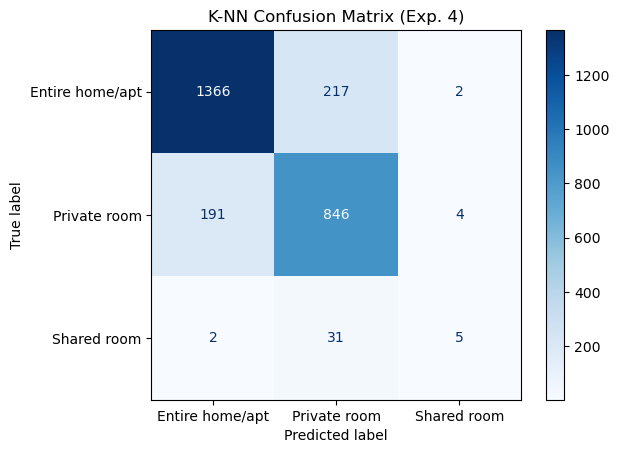

Accuracy: 0.8322072072072072


In [61]:
# Ajustar y predecir
classifier.fit(X_train_set_reduced_preprocessed, y_train_set.values.ravel())
y_pred = classifier.predict(X_test_set_reduced_preprocessed)

# Matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('K-NN Confusion Matrix (Exp. 4)')
plt.show()

# Calcular y devolver la puntuación de precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

Obtenemos un resultado de accuracy muy parecido en el conjunto de entrenamiento y test.

#### Árboles de Decisión

In [62]:
classifier = DecisionTreeClassifier(
    random_state=0,
    class_weight='balanced',
    max_depth=2,
    max_leaf_nodes=3,
    min_samples_split=2
)
tree_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set, scoring="accuracy", cv=10)
print_results(tree_accuracies)

Array de Precisiones = [0.83958724 0.86210131 0.82270169 0.8358349  0.85834897 0.81877934
 0.84225352 0.82723005 0.82816901 0.85446009]

Precisión Media: 0.8389466127597354

Desviación estándar: 0.014485645873480071


El resultado es exactamente igual al del Experimento 3.

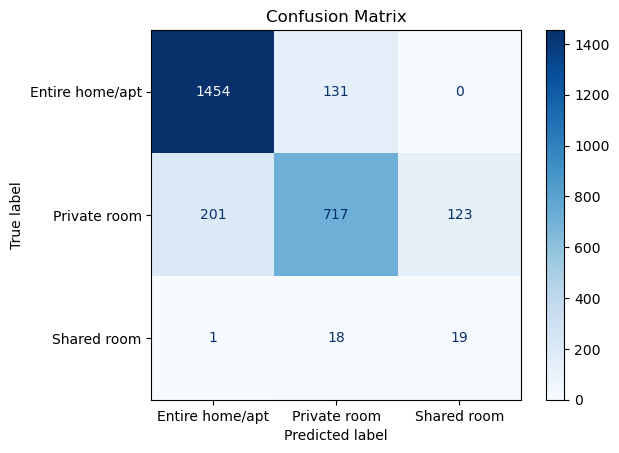

Accuracy: 0.8220720720720721


In [63]:
# Ajustar y predecir
classifier.fit(X_train_set_reduced_preprocessed, y_train_set)
y_pred = classifier.predict(X_test_set_reduced_preprocessed)

# Matriz de confusión
cm = confusion_matrix(y_test_set, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Precisión
print(f"Accuracy: {accuracy_score(y_test_set, y_pred)}")

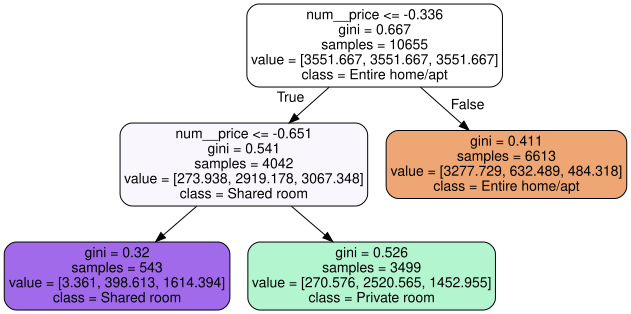

In [64]:
feature_names_list = preprocessing.get_feature_names_out().tolist()
class_names_list = classifier.classes_.tolist()

# Genera un archivo .dot que representa el árbol de decisiones
export_graphviz(
     classifier,
     out_file="decision_tree.dot",
     feature_names=feature_names_list,
     class_names=class_names_list,
     rounded=True,
     filled=True
 )

# Lee y visualiza el archivo .dot generado para inspeccionar el árbol de decisiones
Source.from_file("decision_tree.dot")

El árbol obtenido también es igual al del Experimento 3.

#### Resumen y Conclusiones Experimento 4

- K-NN ha mejorado el accuracy en 0.2 con la reducción de dimensionalidad, pudiendo atribuirse la mejora a una reducción en el ruido de los datos.
- El árbol de decisión llega al mismo resultado porque con los hiperparámetros proporcionados solo utiliza el precio para predecir, y no hemos eliminado la variable precio.

## Resumen de los Resultados

En este apartado comentaremos los experimentos realizados y resultados obtenidos de manera global:

**Experimento 1 - Fase de Experimentación Inicial**

Se han probado los modelos utilizando los parámetros por defecto de los métodos (habiendo aplicado parámetros que puedan mejorar el desbalanceo, tal y como lo solicita el enunciado).
- Los modelos **Naive Bayes** por lo general han obtenido una precisión baja, siendo Gaussian Naive Bayes el peor (sesgado hacia `Shared room` y Bernoulli Naive Bayes el mejor (aunque con un poco sesgado hacia `Entire home/apt` y muy malas predicciones para `Shared room`).
- **K-NN** mejoraba Naive Bayes, aunque no estaba a la altura de los árboles de decisión (posiblemente porque estábamos aplicando MinMaxScaler).
- Los **árboles de decisión** han obtenido la mejor puntuación en cuanto a la precisión, pero han creado un árbol muy complejo y difícil de interpretar. Quizás sobreajustado.

Tabla resumen de la media y desviación estándar obtenida con validación cruzada:

| Modelo                     | Precisión Media  | Desviación Estándar |
|----------------------------|------------------|---------------------|
| Gaussian Naive Bayes       | 0.1559           | 0.0119              |
| Multinomial Naive Bayes    | 0.6554           | 0.0158              |
| Complement Naive Bayes     | 0.6405           | 0.0159              |
| Bernoulli Naive Bayes      | 0.6772           | 0.0133              |
| K-NN                       | 0.7185           | 0.0108              |
| Árboles de Decisión        | 0.8545           | 0.0082              |


Matrices de confusión obtenidas tras probar el modelo en el conjunto de test:

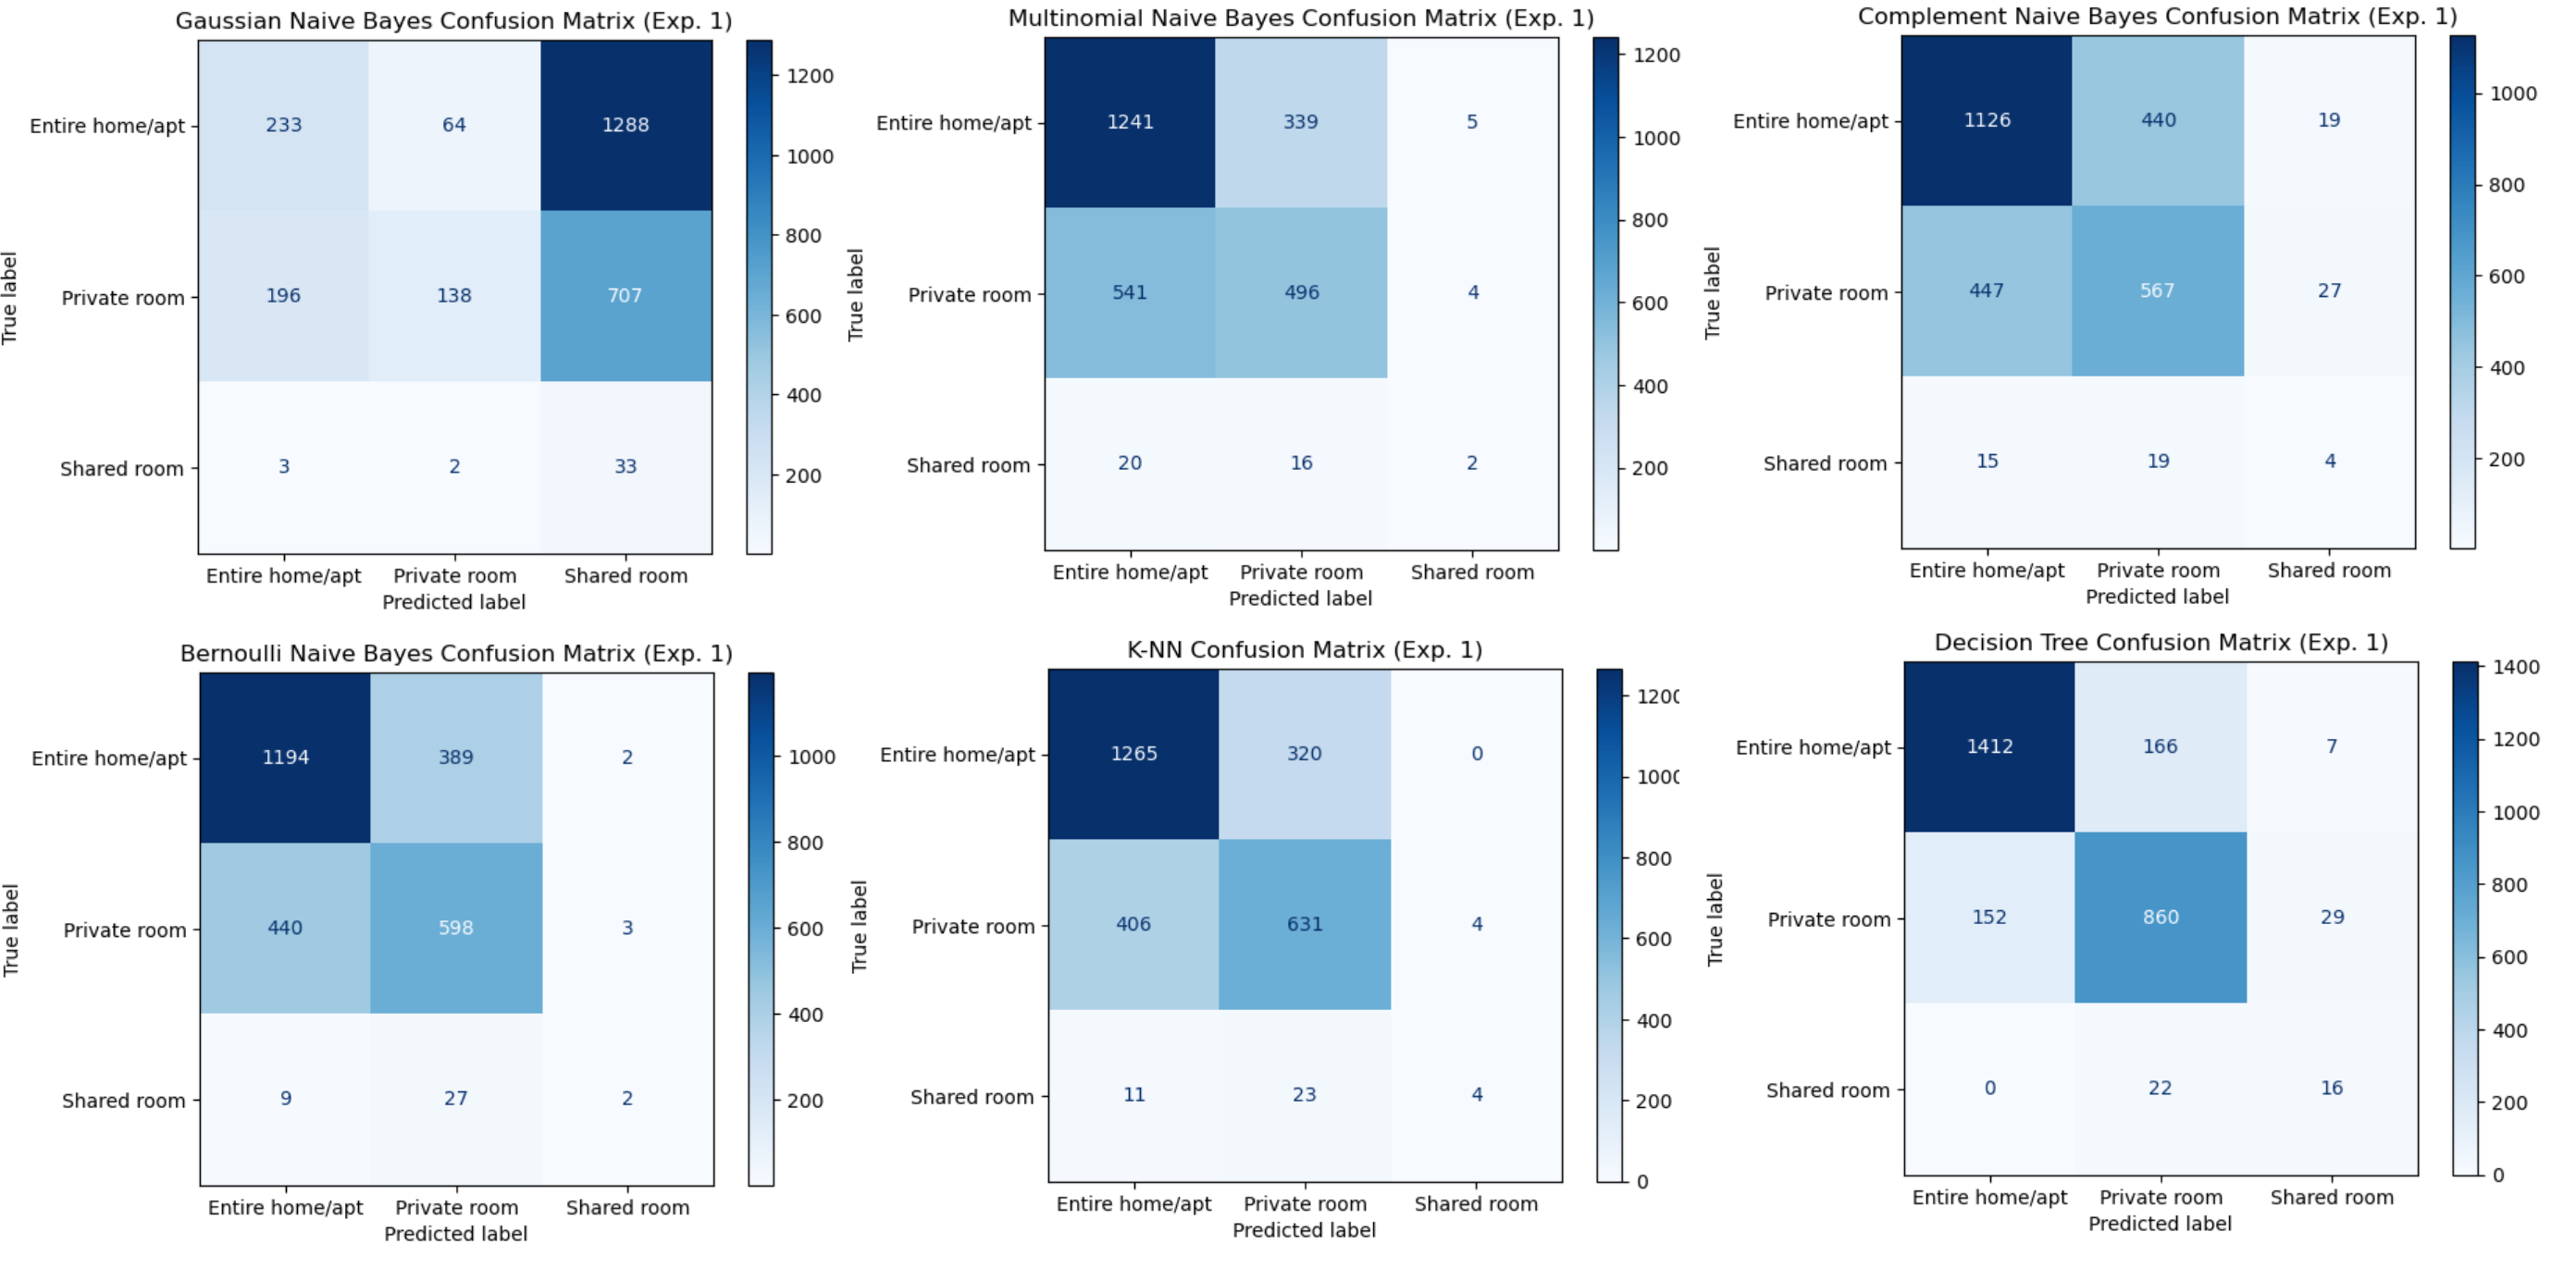

**Experimento 2 - Preprocesamiento con StandardScaler**

El objetivo del experimento era ver cómo afecta en los modelos K-NN y Árboles de Decisión el uso de `StandardScaler` en vez de `MinMaxScaler`, dado que estos modelos pueden manejar valores negativos.

- Las métricas de **K-NN** han mejorado, dado que homogeneiza la escala de las características y mejora el cálculo de la distancia.
- Para los **árboles de decisión** no es tan relevante el escalador, ya que el modelo no depende de la escala de las características, hemos obtenido unas métricas similares al experimento anterior. El árbol sigue siendo muy grande y difícil de interpretar.

Tabla resumen de la media y desviación estándar obtenida con validación cruzada:

| Modelo                     | Precisión Media  | Desviación Estándar |
|----------------------------|------------------|---------------------|
| K-NN                       | 0.8125           | 0.0095              |
| Árboles de Decisión        | 0.8552           | 0.0056              |


Matrices de confusión obtenidas tras probar el modelo en el conjunto de test:



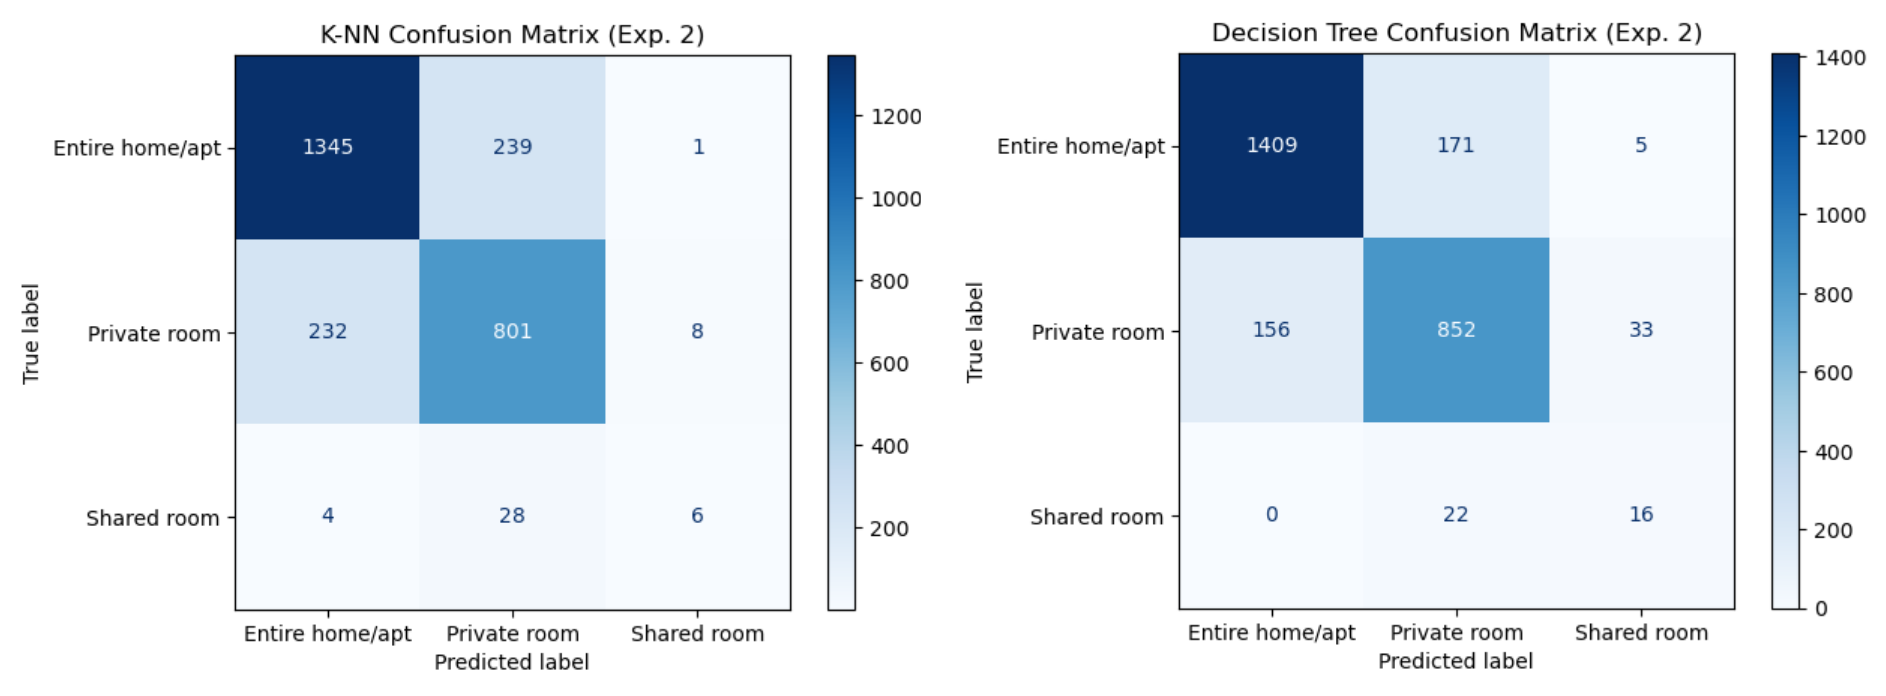

**Experimento 3 - Afinar Hiperparámetros**

El objetivo del experimento ha sido realizar la búsqueda de los hiperparámetros solicitados por el enunciado.

- **KNN:** El número óptimo de k es 5, y coincide con el utilizado en el Experimento 1.
- **Árboles de Decisión:** Tras la optimización, hemos conseguido el resultado `{'max_depth': 2, 'max_leaf_nodes': 3, 'min_samples_split': 2}`, obteniendo un modelo más sencillo (porque los rangos eran menores), y con buena precisión (0.8389), aunque los experimentos previos lograron una precisión ligeramente superior. Este nuevo modelo aporta mejor explicabilidad que los anteriores, y hemos concluido que el precio es definitivamente el atributo de gran relevancia.

Gráfico de búsqueda de K, donde K=5 maximiza la precisión:

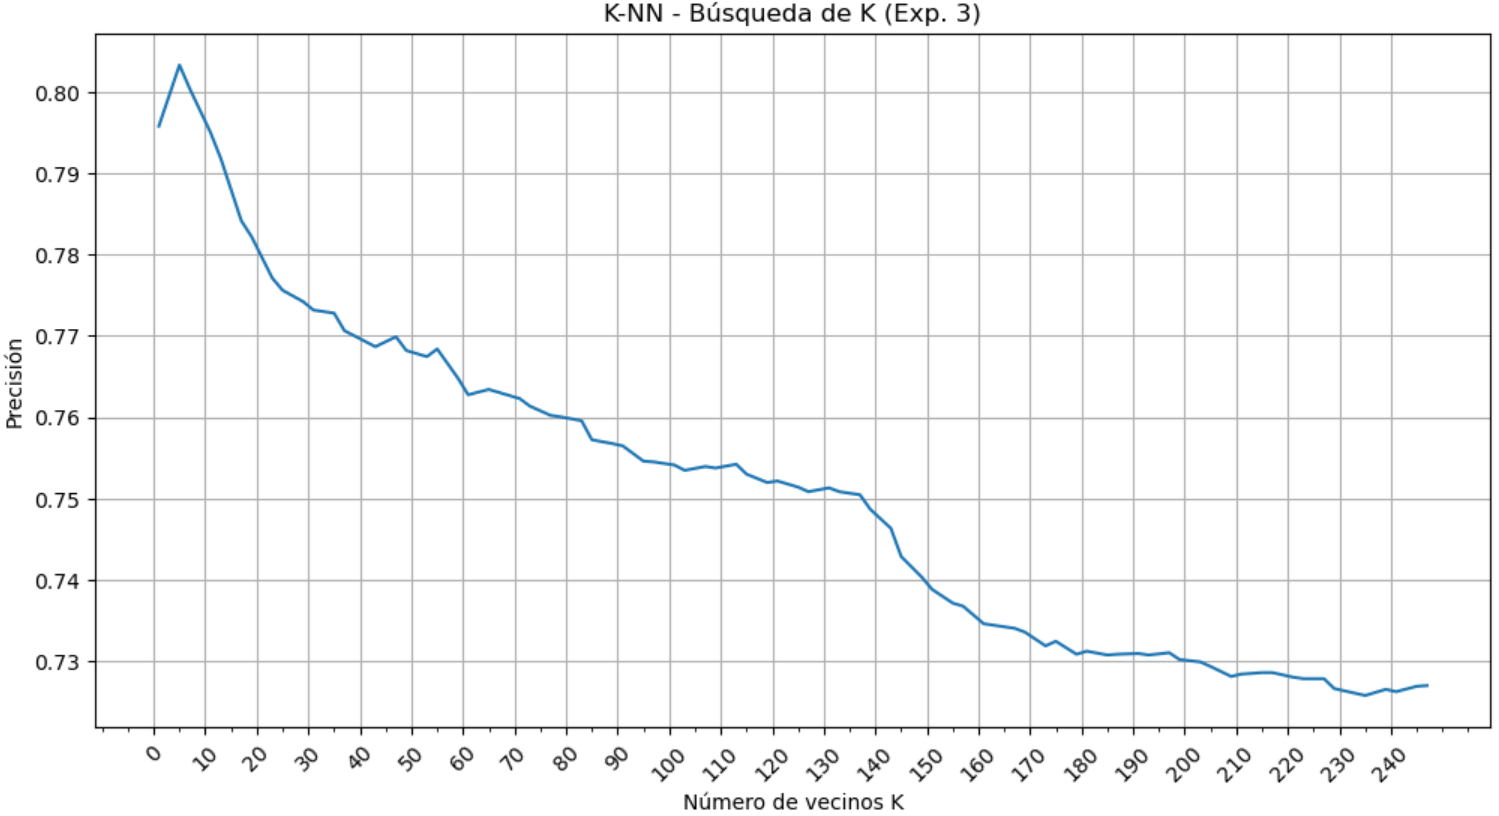

Métricas del árbol de decisión con los nuevos hiperparámetros, obtenidas con validación cruzada:

| Modelo                     | Precisión Media  | Desviación Estándar |
|----------------------------|------------------|---------------------|
| Árboles de Decisión        | 0.8389           | 0.0144              |

Comparación entre experimentos de las matrices de confusión del árbol de decisión (obtenidas tras probar el modelo en el conjunto de test):

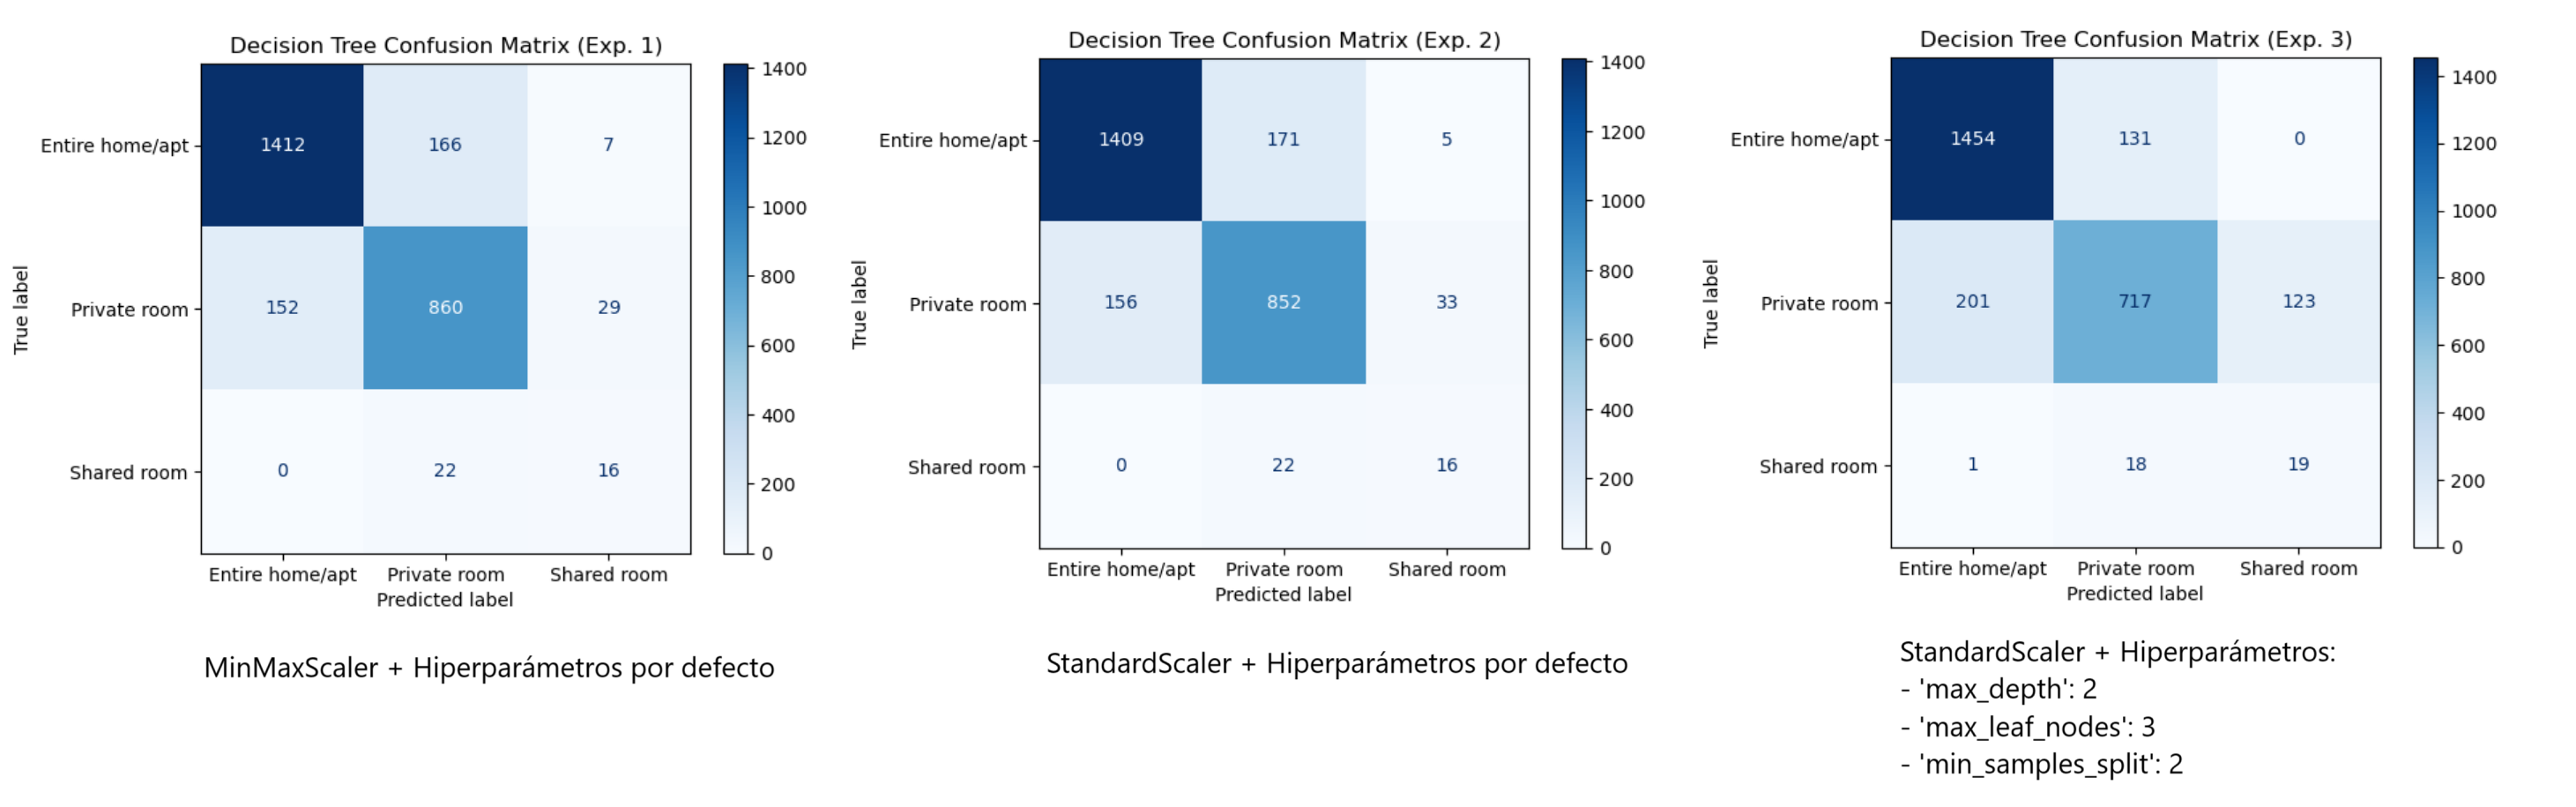

Árbol tras aplicar los hiperparámetros obtenidos, donde vemos que se utiliza el precio a la hora de realizar las decisiones:

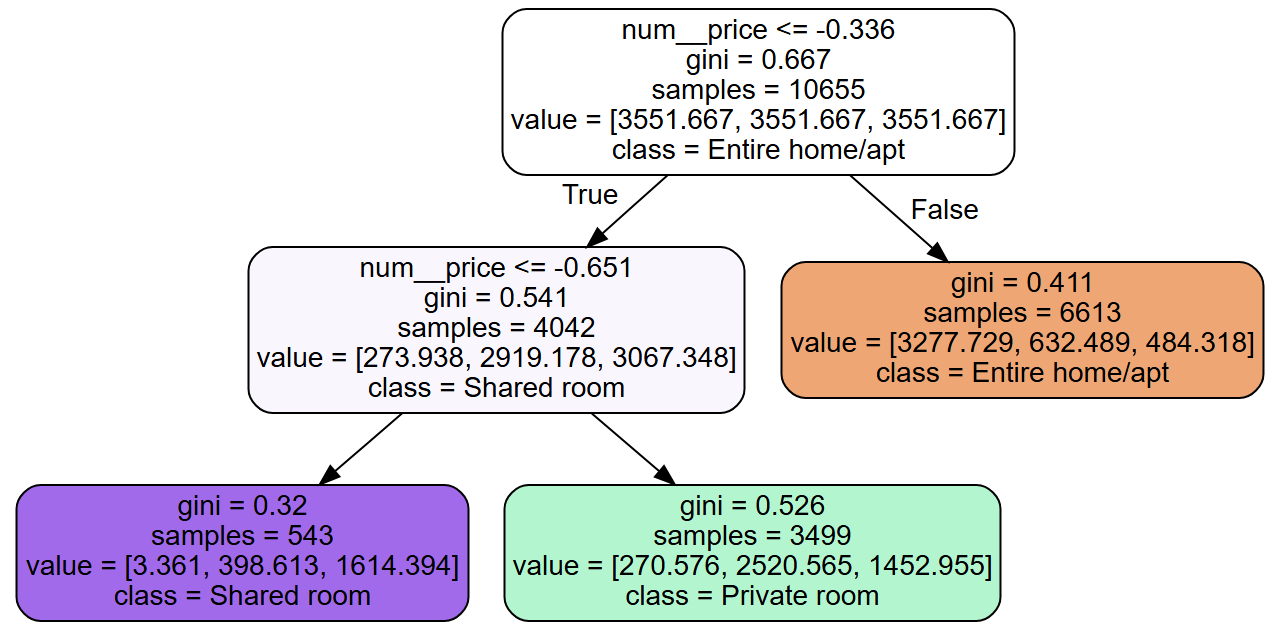

**Experimento 4 - Reducción de la Dimensionalidad**

Experimento extra y de caracter exploratorio para ver cómo afecta la reducción de la dimensionalidad en los modelos. Se han eliminado las columnas:  `latitude` y `longitude`, `neighbourhood_group` y `reviews_per_month`.

- **K-NN** ha mejorado el accuracy en 0.2 con la reducción de dimensionalidad. Podemos atribuir dicha mejora a una reducción en el ruido de los datos, tras eliminar redundancias.
- El **árbol de decisión** llega a exactamente el mismo resultado que en el experimento 3, porque de los hiperparámetros proporcionados solo utiliza el precio para predecir, y no hemos eliminado la variable precio.

Tabla resumen de la media y desviación estándar obtenida con validación cruzada tras aplicar la reducción de dimensionalidad:

| Modelo                     | Precisión Media  | Desviación Estándar |
|----------------------------|------------------|---------------------|
| K-NN                       | 0.8313           | 0.0073              |
| Árboles de Decisión        | 0.8389           | 0.0144              |


Comparación entre experimentos de la matriz de confusión de K-NN (obtenidas tras probar el modelo en el conjunto de test):

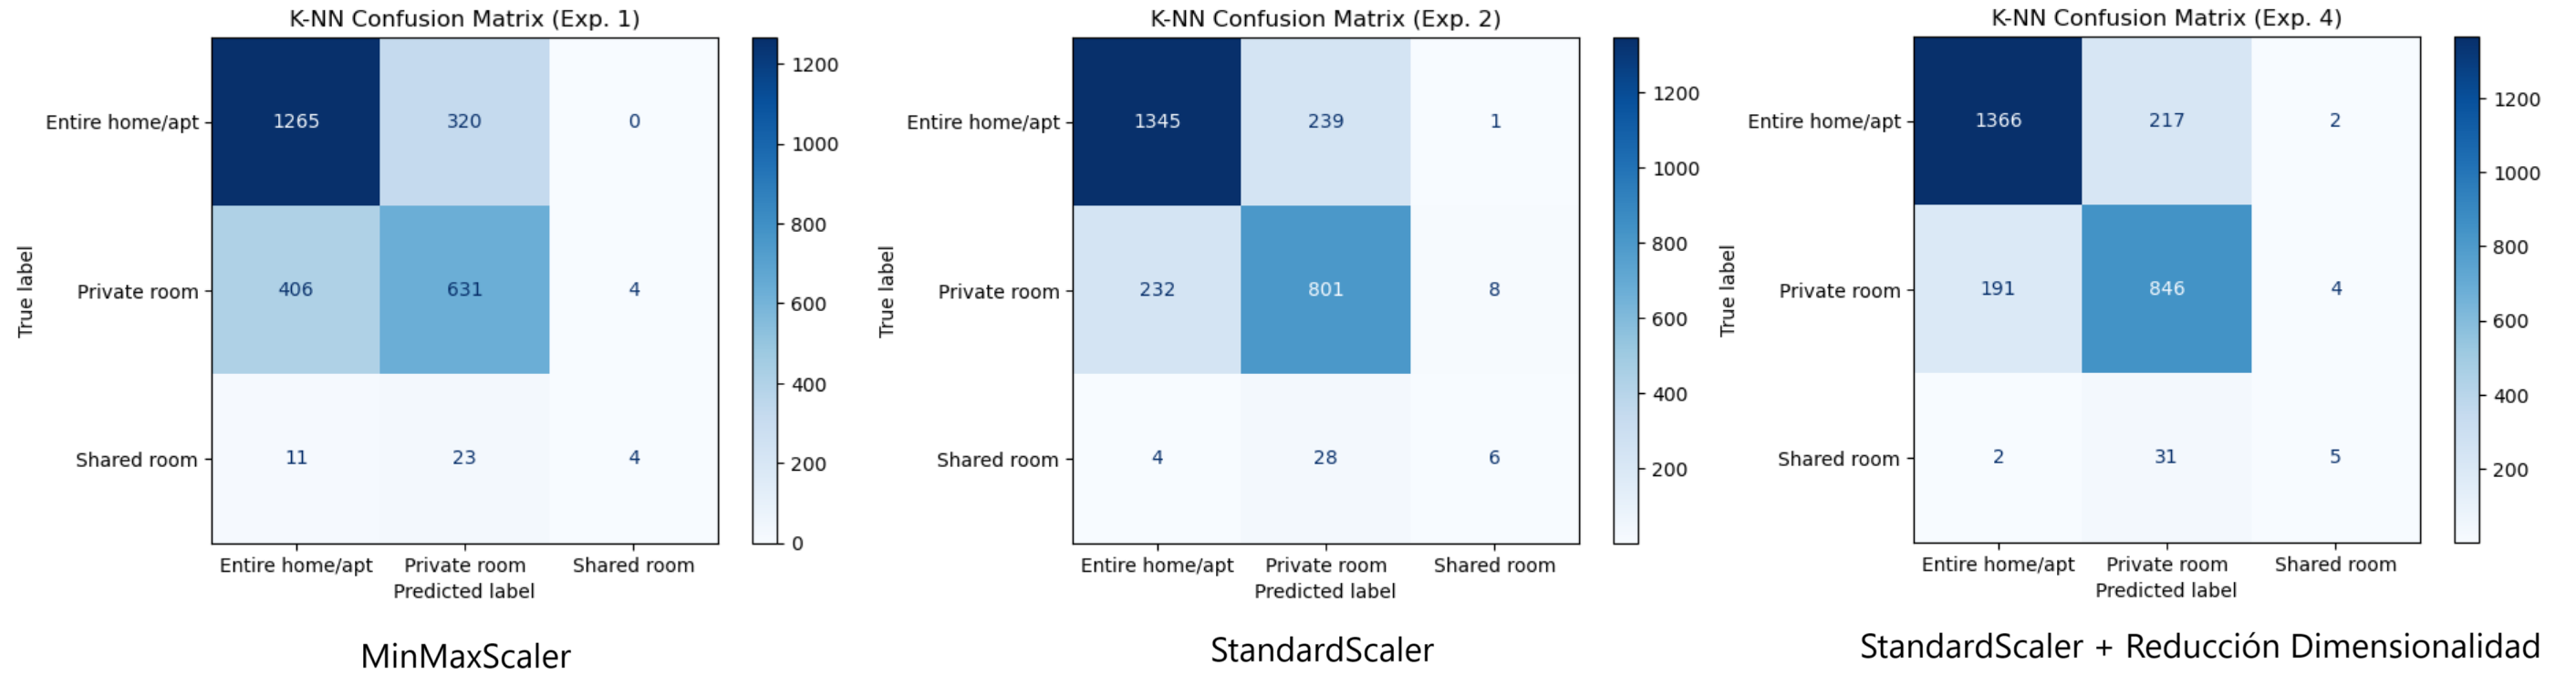

## Conclusiones

En este trabajo se ha realizado un análisis exploratorio de los datos, preprocesamiento y experimentación con varios modelos de machine learning para clasificar tipos de alojamiento en Airbnb en Madrid.

El análisis exploratorio de datos (EDA) comenzó evaluando el DataFrame. Observamos que no hay valores nulos ni entradas duplicadas, lo que facilita el análisis sin necesidad de limpieza adicional. Al analizar las variables numéricas, vimos que las latitudes y longitudes corresponden a Madrid y que el precio variaba significativamente, con un valor máximo que parecía un outlier. La cantidad de noches mínimas también tenía un valor extremo, aunque los demás valores estaban dentro de un rango lógico. No se encontraron distribuciones conocidas (como la distribución normal) en los datos numéricos. Se detectó una correlación entre el número total de reseñas y el promedio de reseñas mensuales, y también se sospechó de posibles interrelaciones con las variables que apuntan a la ubicación, como: latitud, longitud, vecindario, etc. La variable `room_type`, nuestro objetivo, está desbalanceada, con una alta proporción de propiedades de tipo "Entire home/apt" frente a "Shared room", lo cual puede afectar al rendimiento de los modelos.

Para mejorar el rendimiento del modelo, eliminamos algunos outliers en `price` y `minimum_nights`. Dividimos los datos en conjuntos de entrenamiento y prueba (80-20), utilizando muestreo estratificado basado en `room_type` para mantener el balance de clases. Y finalmente, aplicamos un pipeline de preprocesamiento de los datos, empleando `OneHotEncoder` para las variables categóricas y `MinMaxScaler` para escalar las numéricas, ya que algunos algoritmos, como Naive Bayes, requieren datos positivos. Se descartó `OrdinalEncoder` porque asignar un número a cada categoría introduce un sesgo. Se prefirió utilizar `OneHotEncoder` que, pese a añadir muchas dimensiones, no introduce sesgos.

El primer experimento, se probaron varios modelos de clasificación. El modelo Naive Bayes mostró una precisión baja, especialmente el Gaussian Naive Bayes, que tendió a estar sesgado hacia la categoría `Shared room`. El mal rendimiento de Naive Bayes puede deberse a que requiere que los datos tengan una distribución concreta (como Gaussiana, etc.) y que haya independencia entre atributos. Ninguna de las características se cumple con los datos actuales. El mejor Naive Bayes fue el Bernoulli, quizás porque las variables categóricas en forma de binarios le permiten modelar mejor el conjunto de datos. El modelo K-NN presentó una mejora con respecto a Naive Bayes, pero no alcanzó la precisión del árbol de decisión. Este último creó árboles complejos, lo que dificultó la interpretación y aumentó el riesgo de sobreajuste.

En el segundo experimento, se utilizó el `StandardScaler`. Mejoró el rendimiento del K-NN, ya que este escalador normaliza los datos y mejora el cálculo de distancias en el algoritmo. En los árboles de decisión, el uso de `StandardScaler` no tuvo impacto, ya que este modelo no depende de la escala de las características.

En el tercer experimento, se procedió a optimizar los hiperparámetros. Para K-NN se vió que el mejor hiperparámetro era el de por defecto, k=5. Para el árbol de decisión, la optimización permitió crear un modelo más simple y comprensible. A pesar de que la precisión fue ligeramente inferior a la del árbol original, el nuevo modelo resultó más explicativo, destacando la relevancia del precio en las decisiones.

Finalmente, se realizó un cuarto experimento adicional de reducción de dimensionalidad, donde se eliminaron las variables latitud, longitud, neighborhood_group y reviews_per_month. Esta reducción redujo el ruido en los datos y mejoró el rendimiento del modelo K-NN, logrando una mejora de 0.2 en la precisión. Sin embargo, el árbol de decisión mantuvo su rendimiento sin cambios, ya que seguía basando sus predicciones únicamente en el precio.

Tras realizar los experimentos y analizar los resultados, se concluye que el Árbol de Decisión optimizado sería una de las opciones más sólidas para llevar a producción, debido a su buena precisión, simplicidad, eficiencia y facilidad para interpretar los resultados. De todos modos, sería importante monitorear el modelo en producción para asegurarse de que no se sobreajuste a medida que se agregan más datos, ya que este modelo puede tender al sobreajuste. 

## Futuras líneas

En esta sección se presentan algunos posibles pasos futuros de este proyecto:

- **Tratamiento de Latitud y Longitud a través de Clustering**: La bibliografía menciona que una estrategia interesante es tratar las coordenadas geográficas para crear clusters basados en la ubicación de las viviendas. Esto podría dar lugar a una nueva característica que capture la similitud entre las viviendas según su ubicación. Para ello, se podría utilizar un modelo de clustering, como `ClusterSimilarity` de la siguiente forma: `cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)` y luego introducirlo en el pipeline de preprocesamiento así: `("geo", cluster_simil, ["latitude", "longitude"])`.

- **Aplicación de Oversampling**: Primero hemos realizado un análisis preliminar de los datos actuales para evaluar el comportamiento de los modelos con el desbalance entre las clases. Sin embargo, posteriormente se podría aplicar la técnica de oversampling para aumentar la representación de las clases minoritarias, y así comparar los resultados obtenidos.
    - En relación con este punto, surge una reflexión acerca de la naturaleza del dataset: ¿por qué está tan desbalanceado? Una posible explicación es que, dado que Airbnb es una plataforma centrada en el alquiler de viviendas turísticas, el alquiler de viviendas compartidas no tenga sentido y sea un error. Se necesitaría un análisis adicional de la calidad de datos para confirmar esta hipótesis.

- **Reducción de Dimensionalidad**: Como mejora del experimento 4 realizado, se propone aplicar una estrategia de eliminación progresiva de dimensiones. En lugar de realizar la reducción de manera global, se podría llevar a cabo de forma iterativa, eliminando una dimensión a la vez. Esto permitiría observar de manera más precisa cómo cada característica influye en el rendimiento del modelo.

## Bibliografía

- Géron, A. (2021) Hands-on machine learning with scikit-learn and tensorflow: Concepts, tools, and techniques to build Intelligent Systems. 2nd edn. Beijing: O’Reilly.
- Vanderplas, J.T. (2017) Python Data Science Handbook: Essential Tools for working with data. Beijing: O’Reilly.
- Lee, W.-M. (2019) Python machine learning. Indianapolis, IN: Wiley.
- Matplotlib 3.9.2 documentation (2024) Matplotlib documentation - Matplotlib 3.9.2 documentation. Disponible en: https://matplotlib.org/stable/ (Accedido el: 08 de noviembre de 2024).
- Pandas documentation (2024) pandas documentation - pandas 2.2.3 documentation. Disponible en: https://pandas.pydata.org/docs/ (Accedido el: 08 de noviembre de 2024).
- Seaborn User guide and tutorial (2024) User guide and tutorial - seaborn 0.13.2 documentation. Disponible en: https://seaborn.pydata.org/tutorial.html (Accedido el: 08 de noviembre de 2024).
- Numpy User Guide (2024) NumPy user guide - NumPy v2.1 Manual. Disponible en: https://numpy.org/doc/stable/user/index.html#user (Accedido el: 08 de noviembre de 2024).
- Scikit-learn User Guide (2024) scikit. Disponible en: https://scikit-learn.org/stable/user_guide.html (Accedido el: 08 de noviembre de 2024).
- Graphviz Documentation (2022) Graphviz. Disponible en: https://graphviz.org/documentation/ (Accedido el: 08 de noviembre de 2024). 